In [1]:
import os
from pathlib import Path

# Ensure we're in the project root
while not Path("datasets").exists() and Path.cwd() != Path.cwd().parent:
    os.chdir("..")
    
if not Path("datasets").exists():
    raise FileNotFoundError("Cannot find 'datasets' folder. Are you in the right directory?")

print(f"✅ Working directory: {Path.cwd()}")
print(f"✅ Dataset exists: {Path('datasets/pitts-IAL').exists()}")

✅ Working directory: /home/kush/Desktop/major_project_khush
✅ Dataset exists: True


In [2]:

import sys
print(f"Python version: {sys.version}")


print("\n[1.1] Installing PyTorch and Torchvision...")

!pip install torch==2.1.1 torchvision==0.16.1 --index-url https://download.pytorch.org/whl/cu118

Python version: 3.8.0 (default, Nov  6 2019, 21:49:08) 
[GCC 7.3.0]

[1.1] Installing PyTorch and Torchvision...
Looking in indexes: https://download.pytorch.org/whl/cu118


In [3]:
!pip install -q scikit-image==0.21.0   # Paper requirement
!pip install -q opencv-python==4.8.1.78  # Paper requirement

In [4]:

import torch
import torchvision
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ Torchvision version: {torchvision.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")


/home/kush/anaconda3/envs/khush/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ PyTorch version: 2.1.1+cu118
✓ Torchvision version: 0.16.1+cu118
✓ CUDA available: True
✓ GPU: Quadro P5000


In [5]:
print("\n[1.2] Installing OpenAI CLIP v1.0...")
!pip install -q git+https://github.com/openai/CLIP.git@main

import clip

print(f"✓ CLIP installed successfully")
print(f"✓ Available models: {clip.available_models()}")

# Pre-download ViT-B/16 (paper uses this or ViT-B/32)
print("\n[1.2.1] Pre-downloading CLIP ViT-B/16 model...")
try:
    model, preprocess = clip.load("ViT-B/16", device="cpu", jit=False)
    print(f"✓ CLIP ViT-B/16 cached")
    print(f"  - Embedding dim: {model.visual.output_dim}")
    print(f"  - Input size: {model.visual.input_resolution}")
    del model, preprocess
    torch.cuda.empty_cache()
except Exception as e:
    print(f"⚠️  Could not pre-download ViT-B/16: {e}")


[1.2] Installing OpenAI CLIP v1.0...
✓ CLIP installed successfully
✓ Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']

[1.2.1] Pre-downloading CLIP ViT-B/16 model...
✓ CLIP ViT-B/16 cached
  - Embedding dim: 512
  - Input size: 224


In [14]:
#removed for now to avoid confusion -feb 2, 2026


# print("\n[1.2] Installing OpenAI CLIP...")
# !pip install git+https://github.com/openai/CLIP.git

# import clip
# print(f"✓ CLIP installed successfully")
# print(f"✓ Available CLIP models: {clip.available_models()}")

In [9]:
print("\n[1.3] Installing paper-specified libraries...")
!pip install -q matplotlib==3.7.5
!pip install -q scikit-image==0.21.0
!pip install -q opencv-python==4.8.1.78

import matplotlib
import skimage
import cv2

print(f"✓ matplotlib version: {matplotlib.__version__}")
print(f"✓ scikit-image version: {skimage.__version__}")
print(f"✓ opencv version: {cv2.__version__}")


[1.3] Installing paper-specified libraries...
✓ matplotlib version: 3.7.5
✓ scikit-image version: 0.21.0
✓ opencv version: 4.8.1


In [8]:
# 1.4 Additional Utilities (for data loading & training)
# --------------------------------------------
print("\n[1.4] Installing additional utilities...")
!pip install -q pandas==1.5.3
!pip install -q pillow==10.1.0
!pip install -q tqdm==4.66.1
!pip install -q scipy==1.9.3
!pip install -q ftfy==6.1.1
!pip install -q regex==2023.10.3

print("✓ Utility libraries installed")


[1.4] Installing additional utilities...
✓ Utility libraries installed


In [10]:

print("\n[1.3] Installing Hugging Face libraries...")
!pip install -q transformers==4.35.0
!pip install -q huggingface_hub==0.17.1
!pip install -q accelerate==0.25.0

import transformers
print(f"✓ Transformers version: {transformers.__version__}")


[1.3] Installing Hugging Face libraries...
✓ Transformers version: 4.35.0


In [11]:
# 1.6 Verify All Imports
# --------------------------------------------
print("\n[1.6] Verifying imports...")

try:
    import torch
    import torchvision
    import clip
    import matplotlib.pyplot as plt
    import skimage
    import cv2
    import pandas as pd
    import numpy as np
    from PIL import Image
    from tqdm import tqdm
    
    print("✓ All core imports successful!")
    
    # Summary
    print("\n" + "="*70)
    print("📦 PACKAGE SUMMARY (Paper Requirements)")
    print("="*70)
    
    # Check versions match paper
    versions_ok = True
    
    print(f"PyTorch:      {torch.__version__}", end="")
    if torch.__version__ == "2.1.1":
        print(" ✓")
    else:
        print(f" ⚠️  (Paper uses 2.1.1)")
        versions_ok = False
    
    print(f"Torchvision:  {torchvision.__version__}", end="")
    if torchvision.__version__ == "0.16.1":
        print(" ✓")
    else:
        print(f" ⚠️  (Paper uses 0.16.1)")
        versions_ok = False
    
    print(f"CLIP:         Installed ✓")
    print(f"matplotlib:   {matplotlib.__version__} ✓")
    print(f"scikit-image: {skimage.__version__} ✓")
    print(f"opencv:       {cv2.__version__} ✓")
    
    if not versions_ok:
        print("\n⚠️  Some versions differ from paper requirements")
        print("   This may affect reproducibility")
    
    if torch.cuda.is_available():
        print(f"\n🎮 GPU: {torch.cuda.get_device_name(0)}")
        print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        print(f"   CUDA:   {torch.version.cuda}")
    else:
        print("\n❌ No GPU available")
    
    print("="*70)
    
except ImportError as e:
    print(f"\n❌ Import error: {e}")
    print("Please re-run the installation cell")
    raise


[1.6] Verifying imports...
✓ All core imports successful!

📦 PACKAGE SUMMARY (Paper Requirements)
PyTorch:      2.1.1+cu118 ⚠️  (Paper uses 2.1.1)
Torchvision:  0.16.1+cu118 ⚠️  (Paper uses 0.16.1)
CLIP:         Installed ✓
matplotlib:   3.7.5 ✓
scikit-image: 0.21.0 ✓
opencv:       4.8.1 ✓

⚠️  Some versions differ from paper requirements
   This may affect reproducibility

🎮 GPU: Quadro P5000
   Memory: 17.05 GB
   CUDA:   11.8


In [9]:

# try:
#     import torch
#     import torchvision
#     import clip
#     import transformers
#     import pandas as pd
#     import numpy as np
#     from PIL import Image
#     from tqdm import tqdm
#     import gdown

#     print("\n✓ All imports successful!")
#     print(f"\n📦 Package Versions:")
#     print(f"   • PyTorch: {torch.__version__}")
#     print(f"   • Torchvision: {torchvision.__version__}")
#     print(f"   • Transformers: {transformers.__version__}")
#     print(f"   • CUDA Available: {torch.cuda.is_available()}")

#     if torch.cuda.is_available():
#         print(f"   • GPU: {torch.cuda.get_device_name(0)}")
#         print(f"   • GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")



# except ImportError as e:
#     print(f"\n❌ Import error: {e}")
#     print("Please re-run the installation cell.")

In [12]:
!cp "/home/kush/Documents/IAL-datasets/pitts-IAL.zip" ./pitts-IAL.zip


In [13]:
!mkdir -p ./datasets/
!unzip -q pitts-IAL.zip -d ./datasets/

In [14]:
import os

base_path = "./datasets/pitts-IAL"
print("📂 Annotations:", os.listdir(os.path.join(base_path, "annotations")))
print("🖼 Image Folders:", sorted(os.listdir(os.path.join(base_path, "images")))[:5])


📂 Annotations: ['pitts_database.json', 'coords.csv', 'pitts_queries.json', 'pitts_train.json']
🖼 Image Folders: ['000', '001', '002', '003', '004']


In [15]:
def force_model_fp32(addrclip_model):
    """
    Force entire AddressCLIP model to FP32 precision
    
    Critical when using mixed precision (fp16=True) to prevent
    numerical instability in contrastive loss computations.
    
    Args:
        addrclip_model: AddressCLIP model instance
    
    Returns:
        addrclip_model: Same model with FP32 dtype
    """
    # Convert main model container
    addrclip_model.to(dtype=torch.float32)
    
    # Convert CLIP backbone components
    if hasattr(addrclip_model.clip, 'visual'):
        addrclip_model.clip.visual.to(dtype=torch.float32)
    
    if hasattr(addrclip_model.clip, 'transformer'):
        addrclip_model.clip.transformer.to(dtype=torch.float32)
    
    # Convert CLIP projection layers (Parameters, not Modules)
    if hasattr(addrclip_model.clip, 'text_projection'):
        if addrclip_model.clip.text_projection is not None:
            addrclip_model.clip.text_projection = \
                addrclip_model.clip.text_projection.to(torch.float32)
    
    if hasattr(addrclip_model.clip, 'visual_projection'):
        if addrclip_model.clip.visual_projection is not None:
            addrclip_model.clip.visual_projection = \
                addrclip_model.clip.visual_projection.to(torch.float32)
    
    # Convert custom projection heads
    addrclip_model.proj_image.to(dtype=torch.float32)
    addrclip_model.proj_address.to(dtype=torch.float32)
    addrclip_model.proj_caption.to(dtype=torch.float32)
    
    print("✓ Model forced to FP32 precision")
    return addrclip_model


In [16]:
def check_model_dtype(model):
    """
    Debug utility: Check data types of model parameters
    Helps identify mixed precision issues
    """
    print("\nModel Parameter Data Types:")
    print("-" * 60)
    
    dtypes = {}
    for name, param in model.named_parameters():
        dtype_str = str(param.dtype)
        dtypes[dtype_str] = dtypes.get(dtype_str, 0) + 1
    
    for dtype, count in dtypes.items():
        print(f"  {dtype}: {count} parameters")
    
    print("-" * 60)
    
    # Warn if not all FP32
    if len(dtypes) > 1 or 'torch.float32' not in dtypes:
        print("⚠️  Warning: Model has mixed precision parameters")
        print("   Consider calling force_model_fp32(model)")

In [ ]:
#new setup for training - feb 2, 2026

In [ ]:
#again an attempt to get coordinates

In [17]:
"""
CORRECTED COORDINATES CSV GENERATION
Uses filename-based lookup since query images are subsampled from database
"""

import pandas as pd
from scipy.io import loadmat
import os
import numpy as np

def generate_coords_csv_corrected(db_utm_file, q_utm_file, db_images_file, 
                                   q_images_file, output_csv):
    """
    Generate coords.csv using correct mapping strategy:
    
    Key insight: Query images are EXACT duplicates of database images.
    Therefore:
      1. Map database filenames → coordinates (using index // 24)
      2. Lookup query image coordinates from database mapping
      3. This ensures query and database share SAME coordinates for SAME images
    
    This fixes the duplicate filename issue and ensures coordinate consistency.
    """
    
    print("\n" + "="*70)
    print("CORRECTED COORDINATES CSV GENERATION")
    print("="*70)
    
    # ==================
    # 1. Load MATLAB data
    # ==================
    print("\n[1/4] Loading MATLAB files...")
    
    db_data = loadmat(db_utm_file)
    Cdb = db_data['Cdb']  # Shape: (2, 10586)
    
    n_db_locations = Cdb.shape[1]
    
    print(f"  ✓ Database coordinates: {Cdb.shape}")
    print(f"    Easting range: [{Cdb[0].min():.1f}, {Cdb[0].max():.1f}]")
    print(f"    Northing range: [{Cdb[1].min():.1f}, {Cdb[1].max():.1f}]")
    
    # ==================
    # 2. Load image lists
    # ==================
    print("\n[2/4] Loading image filenames...")
    
    with open(db_images_file, 'r') as f:
        db_images = [line.strip() for line in f.readlines() if line.strip()]
    
    with open(q_images_file, 'r') as f:
        q_images = [line.strip() for line in f.readlines() if line.strip()]
    
    n_db_images = len(db_images)
    n_q_images = len(q_images)
    
    print(f"  ✓ Database images: {n_db_images:,}")
    print(f"  ✓ Query images: {n_q_images:,}")
    
    # Check for overlap
    db_set = set(db_images)
    q_set = set(q_images)
    overlap = db_set & q_set
    
    print(f"\n  Filename overlap analysis:")
    print(f"    Query images also in database: {len(overlap):,}")
    
    if len(overlap) == n_q_images:
        print(f"    ✓ ALL query images are in database (expected behavior)")
    else:
        print(f"    ⚠️  Warning: {n_q_images - len(overlap):,} query images NOT in database")
    
    # ==================
    # 3. Build filename → coordinate lookup from database
    # ==================
    print("\n[3/4] Building coordinate lookup table...")
    
    coord_lookup = {}
    
    for i, img_path in enumerate(db_images):
        loc_idx = i // 24
        
        if loc_idx >= n_db_locations:
            print(f"  ⚠️  Warning: Image {i} exceeds location range")
            break
        
        # Store coordinates for this filename
        coord_lookup[img_path] = {
            'utm_easting': float(Cdb[0, loc_idx]),
            'utm_northing': float(Cdb[1, loc_idx]),
            'db_location_idx': loc_idx
        }
    
    print(f"  ✓ Created lookup table with {len(coord_lookup):,} entries")
    
    # ==================
    # 4. Generate CSV entries
    # ==================
    print("\n[4/4] Generating CSV entries...")
    
    csv_rows = []
    
    # Process database images
    for img_path in db_images:
        if img_path in coord_lookup:
            csv_rows.append({
                'filename': img_path,
                'utm_easting': coord_lookup[img_path]['utm_easting'],
                'utm_northing': coord_lookup[img_path]['utm_northing'],
                'is_query': False
            })
    
    # Process query images (lookup from database)
    queries_not_found = []
    
    for img_path in q_images:
        if img_path in coord_lookup:
            csv_rows.append({
                'filename': img_path,
                'utm_easting': coord_lookup[img_path]['utm_easting'],
                'utm_northing': coord_lookup[img_path]['utm_northing'],
                'is_query': True
            })
        else:
            queries_not_found.append(img_path)
    
    if queries_not_found:
        print(f"  ⚠️  Warning: {len(queries_not_found)} query images not found in database")
        print(f"     Examples: {queries_not_found[:5]}")
    
    # ==================
    # 5. Write CSV
    # ==================
    print("\n[5/5] Writing CSV file...")
    
    os.makedirs(os.path.dirname(output_csv), exist_ok=True)
    
    df = pd.DataFrame(csv_rows)
    
    # Save only required columns
    df[['filename', 'utm_easting', 'utm_northing']].to_csv(output_csv, index=False)
    
    print(f"\n✅ Successfully saved: {output_csv}")
    print(f"   Total entries: {len(df):,}")
    print(f"   - Database: {(~df['is_query']).sum():,}")
    print(f"   - Query: {df['is_query'].sum():,}")
    
    return df


def comprehensive_validation(csv_path, db_utm_file, db_images_file, q_images_file):
    """
    Validate the generated CSV thoroughly
    """
    
    print("\n" + "="*70)
    print("COMPREHENSIVE VALIDATION")
    print("="*70)
    
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Load reference data
    Cdb = loadmat(db_utm_file)['Cdb']
    
    with open(db_images_file, 'r') as f:
        db_images = [line.strip() for line in f.readlines() if line.strip()]
    
    with open(q_images_file, 'r') as f:
        q_images = [line.strip() for line in f.readlines() if line.strip()]
    
    all_passed = True
    
    # ==================
    # TEST 1: Row counts
    # ==================
    print("\n[TEST 1] Row Counts")
    
    expected_total = len(db_images) + len(q_images)
    actual_total = len(df)
    
    print(f"  Expected: {expected_total:,} (DB: {len(db_images):,} + Query: {len(q_images):,})")
    print(f"  Actual: {actual_total:,}")
    
    if actual_total == expected_total:
        print(f"  ✅ PASS")
    else:
        print(f"  ❌ FAIL: Count mismatch")
        all_passed = False
    
    # ==================
    # TEST 2: No duplicates
    # ==================
    print("\n[TEST 2] Duplicate Filenames")
    
    duplicates = df['filename'].duplicated().sum()
    
    if duplicates == 0:
        print(f"  ✅ PASS: No duplicates")
    else:
        print(f"  ❌ FAIL: {duplicates} duplicates found")
        all_passed = False
    
    # ==================
    # TEST 3: Missing values
    # ==================
    print("\n[TEST 3] Missing Values")
    
    missing = df[['utm_easting', 'utm_northing']].isna().sum().sum()
    
    if missing == 0:
        print(f"  ✅ PASS: No missing coordinates")
    else:
        print(f"  ❌ FAIL: {missing} missing values")
        all_passed = False
    
    # ==================
    # TEST 4: Query-Database coordinate consistency
    # ==================
    print("\n[TEST 4] Query-Database Coordinate Consistency")
    
    # For each query image, check if its coordinates match the database version
    q_set = set(q_images)
    
    mismatches = []
    
    for img in q_images[:100]:  # Check first 100 queries
        # Get query coordinates from CSV
        q_row = df[df['filename'] == img]
        if len(q_row) == 0:
            continue
        
        q_coords = q_row[['utm_easting', 'utm_northing']].values[0]
        
        # Since this image is also in database, find its database entry
        db_row = df[df['filename'] == img]
        if len(db_row) > 1:  # Should have 2 entries (one DB, one query)
            db_coords = db_row[['utm_easting', 'utm_northing']].values[0]
            
            if not np.allclose(q_coords, db_coords, rtol=1e-5):
                mismatches.append(img)
    
    if len(mismatches) == 0:
        print(f"  ✅ PASS: Query and database coordinates match for same images")
    else:
        print(f"  ❌ FAIL: {len(mismatches)} coordinate mismatches")
        print(f"     Examples: {mismatches[:5]}")
        all_passed = False
    
    # ==================
    # TEST 5: Coordinate correctness (spot check)
    # ==================
    print("\n[TEST 5] Coordinate Value Verification")
    
    # Check 5 random database images
    test_indices = np.random.choice(len(db_images), size=5, replace=False)
    
    coord_errors = []
    
    for idx in test_indices:
        img_path = db_images[idx]
        expected_loc = idx // 24
        expected_coords = Cdb[:, expected_loc]
        
        csv_row = df[df['filename'] == img_path]
        if len(csv_row) == 0:
            continue
        
        csv_coords = csv_row[['utm_easting', 'utm_northing']].values[0]
        
        if not np.allclose(csv_coords, expected_coords, rtol=1e-5):
            coord_errors.append({
                'image': img_path,
                'expected': expected_coords,
                'got': csv_coords
            })
    
    if len(coord_errors) == 0:
        print(f"  ✅ PASS: Coordinates match MATLAB reference")
    else:
        print(f"  ❌ FAIL: {len(coord_errors)} coordinate errors")
        for err in coord_errors:
            print(f"     {err['image']}")
            print(f"       Expected: {err['expected']}")
            print(f"       Got: {err['got']}")
        all_passed = False
    
    # ==================
    # Summary
    # ==================
    print("\n" + "="*70)
    print("VALIDATION SUMMARY")
    print("="*70)
    
    if all_passed:
        print("✅ ALL TESTS PASSED - coords.csv is ready for training!")
    else:
        print("❌ SOME TESTS FAILED - please review errors above")
    
    print("="*70)
    
    return all_passed


# ==================
# MAIN EXECUTION
# ==================

if __name__ == "__main__":
    
    # Generate corrected CSV
    df = generate_coords_csv_corrected(
        db_utm_file='./datasets/pitts-IAL/groundtruth/pittsburgh_database_10586_utm.mat',
        q_utm_file='./datasets/pitts-IAL/groundtruth/pittsburgh_query_1000_utm.mat',
        db_images_file='./datasets/pitts-IAL/groundtruth/imagelist.txt',
        q_images_file='./datasets/pitts-IAL/groundtruth/querylist.txt',
        output_csv='./datasets/pitts-IAL/annotations/coords.csv'
    )
    
    # Validate
    validation_passed = comprehensive_validation(
        csv_path='./datasets/pitts-IAL/annotations/coords.csv',
        db_utm_file='./datasets/pitts-IAL/groundtruth/pittsburgh_database_10586_utm.mat',
        db_images_file='./datasets/pitts-IAL/groundtruth/imagelist.txt',
        q_images_file='./datasets/pitts-IAL/groundtruth/querylist.txt'
    )
    
    # Final statistics
    if validation_passed:
        print("\n" + "="*70)
        print("FINAL STATISTICS")
        print("="*70)
        
        df_final = pd.read_csv('./datasets/pitts-IAL/annotations/coords.csv')
        
        print(f"\n📊 Dataset Summary:")
        print(f"   Total images: {len(df_final):,}")
        print(f"   Unique filenames: {df_final['filename'].nunique():,}")
        print(f"   Coordinate range:")
        print(f"     Easting: [{df_final['utm_easting'].min():.1f}, {df_final['utm_easting'].max():.1f}]")
        print(f"     Northing: [{df_final['utm_northing'].min():.1f}, {df_final['utm_northing'].max():.1f}]")
        
        print(f"\n✅ coords.csv is ready!")
        print(f"   Location: ./datasets/pitts-IAL/annotations/coords.csv")
        print(f"   Ready for: Dataset loading and training")
        print("="*70)


CORRECTED COORDINATES CSV GENERATION

[1/4] Loading MATLAB files...
  ✓ Database coordinates: (2, 10586)
    Easting range: [583289.1, 587061.3]
    Northing range: [4475171.4, 4480086.8]

[2/4] Loading image filenames...
  ✓ Database images: 254,064
  ✓ Query images: 24,000

  Filename overlap analysis:
    Query images also in database: 24,000
    ✓ ALL query images are in database (expected behavior)

[3/4] Building coordinate lookup table...
  ✓ Created lookup table with 254,064 entries

[4/4] Generating CSV entries...

[5/5] Writing CSV file...

✅ Successfully saved: ./datasets/pitts-IAL/annotations/coords.csv
   Total entries: 278,064
   - Database: 254,064
   - Query: 24,000

COMPREHENSIVE VALIDATION

[TEST 1] Row Counts
  Expected: 278,064 (DB: 254,064 + Query: 24,000)
  Actual: 278,064
  ✅ PASS

[TEST 2] Duplicate Filenames
  ❌ FAIL: 24000 duplicates found

[TEST 3] Missing Values
  ✅ PASS: No missing coordinates

[TEST 4] Query-Database Coordinate Consistency
  ✅ PASS: Query

In [18]:
import pandas as pd

df = pd.read_csv('./datasets/pitts-IAL/annotations/coords.csv')

print("="*70)
print("CSV STRUCTURE VERIFICATION")
print("="*70)

# Count occurrences of each filename
filename_counts = df['filename'].value_counts()

print(f"\nFilename occurrence distribution:")
print(f"  Files appearing once: {(filename_counts == 1).sum():,}")
print(f"  Files appearing twice: {(filename_counts == 2).sum():,}")
print(f"  Files appearing 3+ times: {(filename_counts > 2).sum():,}")

# Check specific query image
test_query = '000/000015_pitch1_yaw1.jpg'
test_entries = df[df['filename'] == test_query]

print(f"\nExample: '{test_query}'")
print(f"  Appears {len(test_entries)} times in CSV")
print(f"  Coordinates:")
for idx, row in test_entries.iterrows():
    print(f"    E={row['utm_easting']:.2f}, N={row['utm_northing']:.2f}")

# Verify all are identical coordinates
if len(test_entries) == 2:
    coord_match = (test_entries.iloc[0][['utm_easting', 'utm_northing']].values == 
                   test_entries.iloc[1][['utm_easting', 'utm_northing']].values).all()
    print(f"  Same coordinates: {coord_match}")

print("\n" + "="*70)
print("EXPECTED BEHAVIOR:")
print("  ✓ 24,000 query images appear TWICE (once as DB, once as query)")
print("  ✓ 230,064 database-only images appear ONCE")
print("  ✓ Same image always has SAME coordinates")
print("="*70)

# **Expected output:**
# ```
# Files appearing once: 230,064  (DB-only images)
# Files appearing twice: 24,000  (Query images, also in DB)
# Files appearing 3+ times: 0

# Example: '000/000015_pitch1_yaw1.jpg'
#   Appears 2 times in CSV
#   Coordinates:
#     E=585001.41, N=4477058.99
#     E=585001.41, N=4477058.99  ← Same!
#   Same coordinates: True

CSV STRUCTURE VERIFICATION

Filename occurrence distribution:
  Files appearing once: 230,064
  Files appearing twice: 24,000
  Files appearing 3+ times: 0

Example: '000/000015_pitch1_yaw1.jpg'
  Appears 2 times in CSV
  Coordinates:
    E=585188.40, N=4477215.38
    E=585188.40, N=4477215.38
  Same coordinates: True

EXPECTED BEHAVIOR:
  ✓ 24,000 query images appear TWICE (once as DB, once as query)
  ✓ 230,064 database-only images appear ONCE
  ✓ Same image always has SAME coordinates


In [20]:
# Cell 2: Configuration
from dataclasses import dataclass

import os, json, math, random, time, re, csv
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

DATA_ROOT = "./datasets/pitts-IAL"
ANN_DIR   = os.path.join(DATA_ROOT, "annotations")
TRAIN_JSON = os.path.join(ANN_DIR, "pitts_train.json")
DB_JSON    = os.path.join(ANN_DIR, "pitts_database.json")
Q_JSON     = os.path.join(ANN_DIR, "pitts_queries.json")

RUN_DIR = "./runs/addressclip2"
os.makedirs(RUN_DIR, exist_ok=True)
CSV_LOG = os.path.join(RUN_DIR, "train_log.csv")
LOSS_PNG = os.path.join(RUN_DIR, "loss_curve.png")
ACC_PNG  = os.path.join(RUN_DIR, "accuracy_curve.png")


def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(42)

@dataclass
class Cfg:
    image_size: int = 224
    batch_size: int = 32
    grad_accum: int = 2  
    # #changes made on feb 4
    # batch_size: int = 8  # CHANGE: Reduce to fit 6GB GPU
    # grad_accum: int = 4  # CHANGE: Increase to maintain effective batch=32
    epochs: int = 100
    tau: float = 0.07
    lambda_addr: float = 1.0
    lambda_cap: float = 0.2      # Changed from 0.5
    lambda_geo: float = 0.8       # Changed from 0.2
    lr_heads: float = 3e-4        # ← Higher for random init
    lr_backbone: float = 2.4e-5   # ← Lower for pretrained (INITIAL, not final!)
    weight_decay: float = 0.2
    warmup_ratio: float = 0.1
    freeze_epochs: int = 0
    fp16: bool = True
    device: str = "cuda"
    subset_frac: float = 1.0
    subset_floor: int = 512

CFG = Cfg()
def load_json(path: str) -> Dict[str, list]:
    with open(path, "r") as f:
        return json.load(f)

def normalize_addr(s: str) -> str:
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s,().\-\/&]", "", s)
    return s

In [21]:
# ============================================
# MODEL ARCHITECTURE (CORRECTED)
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import clip

class LinearHead(nn.Module):
    """
    Projection head with L2 normalization
    Maps CLIP features to a common embedding space
    """
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)
    
    def forward(self, x):
        # L2 normalize for contrastive learning
        return F.normalize(self.fc(x), dim=-1)


class AddressCLIP(nn.Module):
    """
    AddressCLIP: Vision-Language Model for Address Localization
    
    Architecture:
      - CLIP ViT-B/16 backbone (pretrained)
      - Three projection heads: image, address, caption
      - Contrastive learning + geography-aware loss
    
    Args:
        proj_dim: Dimension of projection space (default: 512)
        freeze_visual: Freeze CLIP visual encoder
        freeze_text: Freeze CLIP text encoder
        device: Device to load model on
    """
    
    def __init__(self, proj_dim=512, freeze_visual=False, freeze_text=False, device='cuda'):
        super().__init__()
        
        # Load pretrained CLIP
        self.clip, _ = clip.load("ViT-B/16", device=device, jit=False)
        self.clip.float()  # Ensure FP32
        
        # Get embedding dimensions
        # ViT-B/16 has 512-dim outputs for both image and text
        img_dim = self.clip.visual.output_dim  # Should be 512
        txt_dim = self.clip.text_projection.shape[1]  # Should be 512
        
        print(f"  CLIP dimensions: image={img_dim}, text={txt_dim}")
        
        # Projection heads (randomly initialized)
        self.proj_image = LinearHead(img_dim, proj_dim)
        self.proj_address = LinearHead(txt_dim, proj_dim)
        self.proj_caption = LinearHead(txt_dim, proj_dim)
        
        # Freezing strategy
        if freeze_visual:
            print("  Freezing visual encoder")
            for p in self.clip.visual.parameters():
                p.requires_grad = False
        
        if freeze_text:
            print("  Freezing text encoder")
            # Freeze all text components
            for p in self.clip.transformer.parameters():
                p.requires_grad = False
            
            # Freeze embeddings and normalization
            if hasattr(self.clip, 'token_embedding'):
                self.clip.token_embedding.weight.requires_grad = False
            if hasattr(self.clip, 'positional_embedding'):
                self.clip.positional_embedding.requires_grad = False
            if hasattr(self.clip, 'ln_final'):
                for p in self.clip.ln_final.parameters():
                    p.requires_grad = False
    
    def encode_text_raw(self, tokens):
        """
        Encode text through CLIP text encoder
        
        CRITICAL: No @torch.no_grad() decorator!
        We need gradients to flow for training.
        
        Args:
            tokens: Tokenized text [batch_size, seq_len]
        
        Returns:
            Text features [batch_size, text_dim]
        """
        # Token embedding
        x = self.clip.token_embedding(tokens).type(self.clip.dtype)
        
        # Add positional encoding
        x = x + self.clip.positional_embedding.type(self.clip.dtype)
        
        # Transformer layers
        x = x.permute(1, 0, 2)  # NLD -> LND
        x = self.clip.transformer(x)
        x = x.permute(1, 0, 2)  # LND -> NLD
        
        # Layer norm
        x = self.clip.ln_final(x).type(self.clip.dtype)
        
        # Take features from EOS token + project
        x = x[torch.arange(tokens.shape[0]), tokens.argmax(dim=-1)] @ self.clip.text_projection
        
        return x
    
    def encode_text(self, tokens, which="address"):
        """
        Encode text and project to embedding space
        
        Args:
            tokens: Tokenized text
            which: "address" or "caption" (selects projection head)
        
        Returns:
            Normalized embeddings [batch_size, proj_dim]
        """
        x = self.encode_text_raw(tokens)
        
        if which == "address":
            return self.proj_address(x)
        elif which == "caption":
            return self.proj_caption(x)
        else:
            raise ValueError(f"Unknown text type: {which}")
    
    def encode_image(self, images):
        """
        Encode images through CLIP visual encoder
        
        Args:
            images: Image tensor [batch_size, 3, 224, 224]
        
        Returns:
            Normalized embeddings [batch_size, proj_dim]
        """
        img_features = self.clip.encode_image(images).float()
        return self.proj_image(img_features)
    
    def forward(self, images, addr_tokens, cap_tokens):
        """
        Forward pass for training
        
        Args:
            images: Image batch [B, 3, 224, 224]
            addr_tokens: Address tokens [B, seq_len]
            cap_tokens: Caption tokens [B, seq_len]
        
        Returns:
            v: Image embeddings [B, proj_dim]
            a: Address embeddings [B, proj_dim]
            c: Caption embeddings [B, proj_dim]
        """
        v = self.encode_image(images)
        a = self.encode_text(addr_tokens, "address")
        c = self.encode_text(cap_tokens, "caption")
        
        return v, a, c

In [22]:
# ============================================
# LOSS FUNCTIONS (CORRECTED)
# ============================================

def clip_info_nce(v, t, tau=0.07):
    """
    InfoNCE contrastive loss (CLIP-style)
    
    Aligns visual and textual embeddings using contrastive learning.
    Encourages matching pairs to have high similarity, non-matching pairs low.
    
    Args:
        v: Visual embeddings [B, D]
        t: Text embeddings [B, D]
        tau: Temperature parameter (default: 0.07, CLIP standard)
    
    Returns:
        Symmetric contrastive loss (average of image→text and text→image)
    
    Reference: Equation (1) in AddressCLIP paper
    """
    B = v.size(0)
    
    # Normalize embeddings (critical for contrastive learning)
    v = F.normalize(v, dim=-1)
    t = F.normalize(t, dim=-1)
    
    # Compute similarity matrix [B, B]
    logits = (v @ t.t()) / tau
    
    # Labels: diagonal elements are positive pairs
    labels = torch.arange(B, device=v.device)
    
    # Symmetric loss
    loss_i2t = F.cross_entropy(logits, labels)      # Image → Text
    loss_t2i = F.cross_entropy(logits.t(), labels)  # Text → Image
    
    return 0.5 * (loss_i2t + loss_t2i)


def compute_geography_loss(image_embeds, coords):
    """
    Geography-aware loss (Paper Equation 5)
    
    Enforces that geographically close images have similar embeddings.
    Uses Manhattan distance in coordinate space and cosine similarity in embedding space.
    
    Args:
        image_embeds: Image embeddings [B, D]
        coords: UTM coordinates [B, 2] (easting, northing)
    
    Returns:
        MSE loss between feature similarity and geographic proximity
    
    Key difference from paper:
      Paper: MSE(similarity, distance) - high dist → low sim
      This: MSE(similarity, 1-distance) - high dist → low sim (inverted for clarity)
      Both are mathematically equivalent, just different formulations.
    """
    B = image_embeds.size(0)
    
    if B < 2:
        # Need at least 2 samples for pairwise loss
        return torch.tensor(0.0, device=image_embeds.device)
    
    # ==================
    # 1. Normalize coordinates (Paper Equation 3)
    # ==================
    # Min-max normalization to [0, 1] per dimension
    coord_min = coords.min(dim=0, keepdim=True)[0]
    coord_max = coords.max(dim=0, keepdim=True)[0]
    coord_range = coord_max - coord_min
    
    # Avoid division by zero if all coords are identical
    coord_range = torch.where(
        coord_range > 1e-6, 
        coord_range, 
        torch.ones_like(coord_range)
    )
    
    coords_norm = (coords - coord_min) / coord_range
    
    # ==================
    # 2. Geographic distance matrix (Paper uses Manhattan/L1)
    # ==================
    # D_U[i,j] = |coords_i - coords_j|_1
    # Range: [0, 2] after normalization (max when one corner to opposite)
    D_U = torch.cdist(coords_norm, coords_norm, p=1)
    
    # Normalize to [0, 1] for stability
    # Max L1 distance in normalized 2D space is 2 (from (0,0) to (1,1))
    D_U = D_U / 2.0
    
    # ==================
    # 3. Feature similarity matrix
    # ==================
    # Normalize embeddings to unit sphere
    v_norm = F.normalize(image_embeds, dim=-1)
    
    # Cosine similarity matrix [B, B]
    # D_V[i,j] = <v_i, v_j> / (||v_i|| ||v_j||)
    # Range: [-1, 1], but typically [0, 1] for similar concepts
    D_V = v_norm @ v_norm.t()
    
    # ==================
    # 4. Construct target and compute loss
    # ==================
    # Target: High similarity for low distance, low similarity for high distance
    # Invert distance: 1 - D_U maps [0,1] distance to [1,0] similarity
    target_sim = 1.0 - D_U
    
    # MSE loss: Encourages D_V to match target_sim
    # Close images (D_U ≈ 0) → target ≈ 1 → encourages D_V ≈ 1 (high similarity)
    # Distant images (D_U ≈ 1) → target ≈ 0 → encourages D_V ≈ 0 (low similarity)
    loss = F.mse_loss(D_V, target_sim)
    
    return loss


def compute_geography_loss_paper_exact(image_embeds, coords):
    """
    EXACT paper implementation (alternative formulation)
    
    Paper Equation 5: L_geo = (1/N²) Σ(D_V_ij - D_U_ij)²
    
    Where:
      D_V: Similarity matrix (our feature similarities)
      D_U: Distance matrix (geographic distances)
    
    This directly regresses similarity to distance (not 1-distance).
    Effect is similar to above but with inverted target.
    """
    B = image_embeds.size(0)
    
    if B < 2:
        return torch.tensor(0.0, device=image_embeds.device)
    
    # Normalize coordinates
    coord_min = coords.min(dim=0, keepdim=True)[0]
    coord_max = coords.max(dim=0, keepdim=True)[0]
    coord_range = torch.clamp(coord_max - coord_min, min=1e-6)
    coords_norm = (coords - coord_min) / coord_range
    
    # Geographic distance (Manhattan)
    D_U = torch.cdist(coords_norm, coords_norm, p=1)
    D_U = D_U / 2.0  # Normalize to [0, 1]
    
    # Feature similarity
    v_norm = F.normalize(image_embeds, dim=-1)
    D_V = v_norm @ v_norm.t()
    
    # Paper's formulation: MSE(similarity, distance)
    # This means: high distance → expect high similarity value
    # But we want: high distance → LOW similarity
    # So we need to convert similarity to distance: 1 - D_V
    feature_distances = 1.0 - D_V
    
    # Now: MSE(feature_distances, geo_distances)
    # High geo distance → high feature distance (low similarity)
    loss = F.mse_loss(feature_distances, D_U)
    
    return loss

In [23]:
# ============================================
# HELPER: Count Trainable Parameters
# ============================================

def count_parameters(model):
    """Count trainable parameters in model"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\n📊 Model Parameters:")
    print(f"   Total: {total:,}")
    print(f"   Trainable: {trainable:,} ({100*trainable/total:.1f}%)")
    print(f"   Frozen: {total - trainable:,} ({100*(total-trainable)/total:.1f}%)")
    
    return trainable


In [24]:
# ============================================
# USAGE EXAMPLE
# ============================================

if __name__ == "__main__":
    # Test model initialization
    print("="*70)
    print("MODEL INITIALIZATION TEST")
    print("="*70)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Initialize model
    model = AddressCLIP(
        proj_dim=512,
        freeze_visual=False,  # Unfreeze for training
        freeze_text=False,
        device=device
    ).to(device)
    
    # Count parameters
    trainable = count_parameters(model)
    
    # Test forward pass
    print("\n" + "="*70)
    print("FORWARD PASS TEST")
    print("="*70)
    
    batch_size = 4
    
    # Dummy inputs
    dummy_images = torch.randn(batch_size, 3, 224, 224, device=device)
    dummy_addr = clip.tokenize(["123 Main St" for _ in range(batch_size)]).to(device)
    dummy_cap = clip.tokenize(["A street view" for _ in range(batch_size)]).to(device)
    dummy_coords = torch.randn(batch_size, 2, device=device) * 1000  # Fake UTM coords
    
    # Forward pass
    v, a, c = model(dummy_images, dummy_addr, dummy_cap)
    
    print(f"\n✓ Output shapes:")
    print(f"   Image embeddings: {v.shape}")
    print(f"   Address embeddings: {a.shape}")
    print(f"   Caption embeddings: {c.shape}")
    
    # Test losses
    print("\n" + "="*70)
    print("LOSS FUNCTION TEST")
    print("="*70)
    
    loss_addr = clip_info_nce(v, a, tau=0.07)
    loss_cap = clip_info_nce(v, c, tau=0.07)
    loss_geo = compute_geography_loss(v, dummy_coords)
    
    print(f"\n✓ Loss values:")
    print(f"   L_address: {loss_addr.item():.4f}")
    print(f"   L_caption: {loss_cap.item():.4f}")
    print(f"   L_geography: {loss_geo.item():.4f}")
    
    # Test backward pass
    total_loss = loss_addr + 0.2 * loss_cap + 0.8 * loss_geo
    total_loss.backward()
    
    print(f"   Total loss: {total_loss.item():.4f}")
    print(f"\n✓ Backward pass successful!")
    
    print("\n" + "="*70)
    print("ALL TESTS PASSED")
    print("="*70)

MODEL INITIALIZATION TEST
  CLIP dimensions: image=512, text=512

📊 Model Parameters:
   Total: 150,408,705
   Trainable: 150,408,705 (100.0%)
   Frozen: 0 (0.0%)

FORWARD PASS TEST

✓ Output shapes:
   Image embeddings: torch.Size([4, 512])
   Address embeddings: torch.Size([4, 512])
   Caption embeddings: torch.Size([4, 512])

LOSS FUNCTION TEST

✓ Loss values:
   L_address: 1.3866
   L_caption: 1.3866
   L_geography: 0.2592
   Total loss: 1.8713

✓ Backward pass successful!

ALL TESTS PASSED


In [25]:
# ============================================
# DATASET CLASSES (CORRECTED & OPTIMIZED)  -->new feb3 2026
# ============================================

import clip
import torch
import os
from PIL import Image
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import random
import json
import torchvision.transforms as T
from pathlib import Path
from typing import Dict, Tuple, Optional

# CLIP normalization constants
MEAN = (0.48145466, 0.4578275, 0.40821073)
STD = (0.26862954, 0.26130258, 0.27577711)

# ============================================
# TRANSFORMS
# ============================================

def get_train_transforms(image_size=224):
    """
    Training augmentations for AddressCLIP
    
    Augmentations:
      - Resize + CenterCrop (standard CLIP)
      - ColorJitter (mild, preserves visual features)
    
    Note: No random crops or flips - address localization needs
    consistent viewpoint and scene context
    """
    return T.Compose([
        T.Resize(image_size, interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(image_size),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])


def get_eval_transforms(image_size=224):
    """Evaluation transforms (no augmentation)"""
    return T.Compose([
        T.Resize(image_size, interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])

In [26]:
# ============================================
# PITTS-IAL TRAINING DATASET
# ============================================

class PittsIALTrain(Dataset):
    """
    Pitts-IAL Training Dataset
    
    Loads images with their addresses, captions, and coordinates.
    Used for training AddressCLIP with three losses:
      - Image-address contrastive
      - Image-caption contrastive  
      - Geography-aware loss
    
    Args:
        root: Dataset root directory
        json_path: Path to train.json
        coords_file: Path to coords.csv
        transform: Image transformations
        subset_frac: Fraction of data to use (for debugging)
        subset_floor: Minimum samples even if subset_frac is small
    """
    
    def __init__(self, root, json_path, coords_file, transform, 
                 subset_frac=1.0, subset_floor=1):
        self.root = Path(root)
        self.transform = transform
        
        # Load JSON annotations
        print(f"  Loading training annotations from {json_path}...")
        with open(json_path, 'r') as f:
            self.data = json.load(f)
        
        self.keys = list(self.data.keys())
        
        # Subset sampling (for debugging or quick experiments)
        n_full = len(self.keys)
        n_keep = max(int(round(n_full * subset_frac)), subset_floor)
        
        if subset_frac < 1.0:
            print(f"  ⚠️  Using subset: {n_keep}/{n_full} ({subset_frac*100:.0f}%)")
            rng = random.Random(123)  # Fixed seed for reproducibility
            rng.shuffle(self.keys)
            self.keys = self.keys[:n_keep]
        
        # Load coordinates
        print(f"  Loading coordinates from {coords_file}...")
        coords_df = pd.read_csv(coords_file)
        
        # Build coordinate lookup
        # Key insight: JSON keys have paths like "000/000123_pitch1_yaw1.jpg"
        # CSV has filenames like "000/000123_pitch1_yaw1.jpg"
        # We need to match them properly
        
        self.coords_dict = {}
        missing_coords = []
        
        for _, row in coords_df.iterrows():
            filename = row['filename']
            # Try both full path and basename as keys
            self.coords_dict[filename] = (
                float(row['utm_easting']), 
                float(row['utm_northing'])
            )
            # Also store with just basename
            basename = os.path.basename(filename)
            self.coords_dict[basename] = (
                float(row['utm_easting']), 
                float(row['utm_northing'])
            )
        
        print(f"  ✓ Loaded {len(coords_df)} coordinate entries")
        
        # Build image path cache for faster loading
        print(f"  Building image path cache...")
        self.path_cache = self._build_path_cache()
        
        # Validate dataset
        self._validate_dataset()
        
        print(f"  ✓ Training dataset ready: {len(self)} images")
    
    def _build_path_cache(self) -> Dict[str, str]:
        """
        Pre-compute image paths to avoid repeated file existence checks
        
        Returns:
            Dictionary mapping JSON keys to actual file paths
        """
        cache = {}
        not_found = []
        
        # Possible image subdirectories
        image_dirs = [
            "",  # Root
            *[f"images/{i:03d}" for i in range(11)],  # images/000 to images/010
            "images/queries_real"
        ]
        
        for key in self.keys:
            # Remove leading "./" if present
            rel_path = key[2:] if key.startswith("./") else key
            
            # Try absolute path first
            if os.path.isabs(rel_path) and os.path.exists(rel_path):
                cache[key] = rel_path
                continue
            
            # Try relative to root
            direct_path = self.root / rel_path
            if direct_path.exists():
                cache[key] = str(direct_path)
                continue
            
            # Try in subdirectories
            filename = os.path.basename(rel_path)
            found = False
            
            for subdir in image_dirs:
                candidate = self.root / subdir / filename
                if candidate.exists():
                    cache[key] = str(candidate)
                    found = True
                    break
            
            if not found:
                not_found.append(key)
        
        if not_found:
            print(f"  ⚠️  Warning: {len(not_found)} images not found")
            if len(not_found) <= 5:
                for k in not_found:
                    print(f"      - {k}")
        
        return cache
    
    def _validate_dataset(self):
        """Check for common issues"""
        issues = []
        
        # Check coordinate coverage
        keys_with_coords = 0
        for key in self.keys[:100]:  # Sample first 100
            filename = os.path.basename(key)
            if filename in self.coords_dict or key in self.coords_dict:
                keys_with_coords += 1
        
        coverage = 100 * keys_with_coords / min(100, len(self.keys))
        
        if coverage < 90:
            issues.append(f"Low coordinate coverage: {coverage:.1f}%")
        
        # Check image paths
        if len(self.path_cache) < 0.9 * len(self.keys):
            issues.append(f"Many images not found: {len(self.path_cache)}/{len(self.keys)}")
        
        if issues:
            print(f"  ⚠️  Dataset validation warnings:")
            for issue in issues:
                print(f"      - {issue}")
    
    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, idx):
        key = self.keys[idx]
        vals = self.data[key]
        
        # Extract text annotations
        caption = str(vals[0]) if len(vals) > 0 else ""
        addr_verbose = str(vals[1]) if len(vals) > 1 else ""
        addr_canon = str(vals[2]) if len(vals) > 2 else addr_verbose
        address = addr_canon.strip() or addr_verbose.strip()
        
        # Combine caption and address (as per paper)
        # Paper: "we introduce additional scene captions as a supplement to address text"
        cap_text = f"{caption} {address}" if caption else address
        
        # Load and transform image
        img_path = self.path_cache.get(key)
        if img_path is None:
            # Fallback: try to find image (slower)
            img_path = self._resolve_path_fallback(key)
        
        try:
            img = Image.open(img_path).convert("RGB")
            img = self.transform(img)
        except Exception as e:
            print(f"Error loading image {key}: {e}")
            # Return a blank image as fallback
            img = torch.zeros(3, 224, 224)
        
        # Get coordinates
        # Try multiple lookup strategies
        coords = None
        
        # Strategy 1: Full key
        if key in self.coords_dict:
            coords = self.coords_dict[key]
        # Strategy 2: Basename
        elif os.path.basename(key) in self.coords_dict:
            coords = self.coords_dict[os.path.basename(key)]
        # Strategy 3: Without leading path
        elif key.lstrip("./") in self.coords_dict:
            coords = self.coords_dict[key.lstrip("./")]
        
        if coords is None:
            # Default to origin (will be caught in validation)
            coords = (0.0, 0.0)
            print(f"⚠️  Missing coordinates for: {key}")
        
        coords_tensor = torch.tensor(coords, dtype=torch.float32)
        
        return {
            "image": img,
            "addr_tokens": clip.tokenize(address, truncate=True)[0],
            "cap_tokens": clip.tokenize(cap_text, truncate=True)[0],
            "coords": coords_tensor
        }
    
    def _resolve_path_fallback(self, key: str) -> str:
        """Fallback path resolution (slower)"""
        rel_path = key[2:] if key.startswith("./") else key
        
        if os.path.isabs(rel_path) and os.path.exists(rel_path):
            return rel_path
        
        filename = os.path.basename(rel_path)
        
        # Try subdirectories
        for subdir in ["", "images/000", "images/001", "images/002", "images/003",
                      "images/004", "images/005", "images/006", "images/007",
                      "images/008", "images/009", "images/010", "images/queries_real"]:
            candidate = self.root / subdir / filename
            if candidate.exists():
                return str(candidate)
        
        # Last resort
        return str(self.root / rel_path)

In [27]:
# ============================================
# PITTS-IAL QUERY DATASET
# ============================================

class PittsIALQueries(Dataset):
    """
    Pitts-IAL Query Dataset
    
    Used for evaluation: given query images, retrieve their addresses
    from the database.
    
    Args:
        root: Dataset root directory
        json_path: Path to queries.json
        coords_file: Path to coords.csv
        transform: Image transformations (no augmentation)
    """
    
    def __init__(self, root, json_path, coords_file, transform):
        self.root = Path(root)
        self.transform = transform
        
        # Load annotations
        with open(json_path, 'r') as f:
            self.data = json.load(f)
        
        self.keys = list(self.data.keys())
        
        # Load coordinates
        coords_df = pd.read_csv(coords_file)
        
        self.coords_dict = {}
        for _, row in coords_df.iterrows():
            filename = row['filename']
            coords = (float(row['utm_easting']), float(row['utm_northing']))
            self.coords_dict[filename] = coords
            self.coords_dict[os.path.basename(filename)] = coords
        
        # Build path cache
        self.path_cache = self._build_path_cache()
        
        print(f"  ✓ Query dataset ready: {len(self)} images")
    
    def _build_path_cache(self) -> Dict[str, str]:
        """Build image path cache"""
        cache = {}
        
        image_dirs = [
            "",
            *[f"images/{i:03d}" for i in range(11)],
            "images/queries_real"
        ]
        
        for key in self.keys:
            rel_path = key[2:] if key.startswith("./") else key
            
            if os.path.isabs(rel_path) and os.path.exists(rel_path):
                cache[key] = rel_path
                continue
            
            direct_path = self.root / rel_path
            if direct_path.exists():
                cache[key] = str(direct_path)
                continue
            
            filename = os.path.basename(rel_path)
            for subdir in image_dirs:
                candidate = self.root / subdir / filename
                if candidate.exists():
                    cache[key] = str(candidate)
                    break
        
        return cache
    
    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, idx):
        key = self.keys[idx]
        vals = self.data[key]
        
        # Ground truth address
        addr_verbose = str(vals[1]) if len(vals) > 1 else ""
        addr_canon = str(vals[2]) if len(vals) > 2 else addr_verbose
        gt_address = addr_canon.strip() or addr_verbose.strip()
        
        # Load image
        img_path = self.path_cache.get(key, str(self.root / key))
        
        try:
            img = Image.open(img_path).convert("RGB")
            img = self.transform(img)
        except Exception as e:
            print(f"Error loading query image {key}: {e}")
            img = torch.zeros(3, 224, 224)
        
        # Get coordinates
        coords = self.coords_dict.get(
            os.path.basename(key),
            self.coords_dict.get(key, (0.0, 0.0))
        )
        coords_tensor = torch.tensor(coords, dtype=torch.float32)
        
        return {
            "image": img,
            "gt": normalize_addr(gt_address),
            "coords": coords_tensor
        }



In [28]:
# ============================================
# DATABASE ADDRESSES (Gallery)
# ============================================

class PittsIALDatabaseAddresses(Dataset):
    """
    Database of unique addresses for retrieval
    
    Extracts all unique addresses from database JSON.
    Used during evaluation: model retrieves addresses from this gallery.
    """
    
    def __init__(self, json_path):
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        keys = list(data.keys())
        
        # Extract unique normalized addresses
        unique_addrs = {}
        
        for key in keys:
            vals = data[key]
            addr_verbose = str(vals[1]) if len(vals) > 1 else ""
            addr_canon = str(vals[2]) if len(vals) > 2 else addr_verbose
            addr_str = addr_canon.strip() or addr_verbose.strip()
            
            addr_norm = normalize_addr(addr_str)
            
            if addr_norm and addr_norm not in unique_addrs:
                unique_addrs[addr_norm] = addr_str
        
        self.norm = list(unique_addrs.keys())
        self.text = [unique_addrs[n] for n in self.norm]
        
        print(f"  ✓ Database gallery: {len(self)} unique addresses")
    
    def __len__(self):
        return len(self.text)
    
    def __getitem__(self, idx):
        return self.text[idx]


# ============================================
# COLLATE FUNCTION
# ============================================

def collate_train(batch):
    """
    Collate function for training batches
    
    Stacks images, tokens, and coordinates into batch tensors
    """
    return {
        "images": torch.stack([b["image"] for b in batch], 0),
        "addr_tokens": torch.stack([b["addr_tokens"] for b in batch], 0),
        "cap_tokens": torch.stack([b["cap_tokens"] for b in batch], 0),
        "coords": torch.stack([b["coords"] for b in batch], 0),
    }


In [29]:

# ============================================
# DATASET INITIALIZATION
# ============================================

def create_datasets(cfg):
    """
    Create train/query/database datasets
    
    Args:
        cfg: Configuration object with paths and settings
    
    Returns:
        train_ds, train_loader, queries_ds, queries_loader, db_ds
    """
    
    print("\n" + "="*70)
    print("CREATING DATASETS")
    print("="*70)
    
    # Transforms
    train_tf = get_train_transforms(cfg.image_size)
    eval_tf = get_eval_transforms(cfg.image_size)
    
    # Training dataset
    print("\n[1/3] Training dataset:")
    train_ds = PittsIALTrain(
        root=cfg.data_root,
        json_path=cfg.train_json,
        coords_file=cfg.coords_csv,
        transform=train_tf,
        subset_frac=cfg.subset_frac,
        subset_floor=cfg.subset_floor
    )
    
    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        collate_fn=collate_train,
        drop_last=True,
        persistent_workers=True  # Faster data loading
    )
    
    # Query dataset
    print("\n[2/3] Query dataset:")
    queries_ds = PittsIALQueries(
        root=cfg.data_root,
        json_path=cfg.queries_json,
        coords_file=cfg.coords_csv,
        transform=eval_tf
    )
    
    queries_loader = DataLoader(
        queries_ds,
        batch_size=64,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    # Database addresses
    print("\n[3/3] Database gallery:")
    db_ds = PittsIALDatabaseAddresses(cfg.database_json)
    
    print("\n" + "="*70)
    print("DATASET SUMMARY")
    print("="*70)
    print(f"  Training images: {len(train_ds):,}")
    print(f"  Training batches: {len(train_loader):,}")
    print(f"  Query images: {len(queries_ds):,}")
    print(f"  Unique addresses: {len(db_ds):,}")
    print("="*70)
    
    return train_ds, train_loader, queries_ds, queries_loader, db_ds

In [31]:
# ============================================
# USAGE
# ============================================

if __name__ == "__main__":
    # Assuming CFG is defined
    from dataclasses import dataclass
    
    @dataclass
    class TestCFG:
        data_root = "./datasets/pitts-IAL"
        train_json = "./datasets/pitts-IAL/annotations/pitts_train.json"
        queries_json = "./datasets/pitts-IAL/annotations/pitts_queries.json"
        database_json = "./datasets/pitts-IAL/annotations/pitts_database.json"
        coords_csv = "./datasets/pitts-IAL/annotations/coords.csv"
        image_size = 224
        batch_size = 32
        subset_frac = 1.0  # Use 1% for testing
        subset_floor = 100
    
    cfg = TestCFG()
    
    train_ds, train_loader, queries_ds, queries_loader, db_ds = create_datasets(cfg)
    
    # Test loading a batch
    print("\n" + "="*70)
    print("TESTING BATCH LOADING")
    print("="*70)
    
    batch = next(iter(train_loader))
    
    print(f"\nBatch contents:")
    print(f"  Images: {batch['images'].shape}")
    print(f"  Address tokens: {batch['addr_tokens'].shape}")
    print(f"  Caption tokens: {batch['cap_tokens'].shape}")
    print(f"  Coordinates: {batch['coords'].shape}")
    print(f"\nCoordinate statistics:")
    print(f"  Min: {batch['coords'].min(dim=0)[0]}")
    print(f"  Max: {batch['coords'].max(dim=0)[0]}")
    print(f"  Mean: {batch['coords'].mean(dim=0)}")
    
    print("\n✓ Dataset loading successful!")


CREATING DATASETS

[1/3] Training dataset:
  Loading training annotations from ./datasets/pitts-IAL/annotations/pitts_train.json...
  Loading coordinates from ./datasets/pitts-IAL/annotations/coords.csv...
  ✓ Loaded 278064 coordinate entries
  Building image path cache...
  ✓ Training dataset ready: 177840 images

[2/3] Query dataset:
  ✓ Query dataset ready: 19152 images

[3/3] Database gallery:
  ✓ Database gallery: 419 unique addresses

DATASET SUMMARY
  Training images: 177,840
  Training batches: 5,557
  Query images: 19,152
  Unique addresses: 419

TESTING BATCH LOADING

Batch contents:
  Images: torch.Size([32, 3, 224, 224])
  Address tokens: torch.Size([32, 77])
  Caption tokens: torch.Size([32, 77])
  Coordinates: torch.Size([32, 2])

Coordinate statistics:
  Min: tensor([ 584039.8750, 4475918.5000])
  Max: tensor([ 586776.6875, 4478557.0000])
  Mean: tensor([ 585345.1250, 4477165.0000])

✓ Dataset loading successful!


In [ ]:
#new training loop - feb3 2026

In [32]:
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm import tqdm
import matplotlib.pyplot as plt
import clip
import csv
import math
import os
import time
import re
import numpy as np
from typing import Tuple, List, Optional
from dataclasses import asdict

# ============================================
# PATHS
# ============================================

RUN_DIR = "./runs/addressclip2"
os.makedirs(RUN_DIR, exist_ok=True)

CSV_LOG = os.path.join(RUN_DIR, "log.csv")
LOSS_PNG = os.path.join(RUN_DIR, "loss.png")
ACC_PNG = os.path.join(RUN_DIR, "acc.png")
SAMPLES_PNG = os.path.join(RUN_DIR, "samples.png")
best_path = os.path.join(RUN_DIR, "best.pt")
last_path = os.path.join(RUN_DIR, "last.pt")


# ============================================
# OPTIMIZER
# ============================================

def build_optimizer(model, cfg):
    """
    Build optimizer with separate learning rates for heads and backbone
    
    Strategy:
      - Projection heads: Higher LR (randomly initialized)
      - CLIP backbone: Lower LR (pretrained)
    
    Args:
        model: AddressCLIP model
        cfg: Configuration object
    
    Returns:
        AdamW optimizer with parameter groups
    """
    # Projection heads (randomly initialized)
    heads = (
        list(model.proj_image.parameters()) +
        list(model.proj_address.parameters()) +
        list(model.proj_caption.parameters())
    )
    
    # CLIP backbone (pretrained, only trainable params)
    backbone = [p for p in model.clip.parameters() if p.requires_grad]
    
    print(f"\n📊 Optimizer parameter groups:")
    print(f"   Projection heads: {sum(p.numel() for p in heads):,} params @ LR {cfg.lr_heads:.2e}")
    print(f"   CLIP backbone: {sum(p.numel() for p in backbone):,} params @ LR {cfg.lr_backbone:.2e}")
    
    optimizer = AdamW([
        {"params": heads, "lr": cfg.lr_heads},
        {"params": backbone, "lr": cfg.lr_backbone},
    ], weight_decay=cfg.weight_decay)
    
    return optimizer


In [33]:

# ============================================
# LEARNING RATE SCHEDULER
# ============================================

def cosine_schedule_with_warmup(optimizer, num_warmup, num_total, lr_min_ratio=0.001):
    """
    Cosine annealing schedule with linear warmup
    
    Schedule:
      - [0, num_warmup]: Linear warmup from 0 to base_lr
      - [num_warmup, num_total]: Cosine decay from base_lr to base_lr * lr_min_ratio
    
    Paper uses:
      - base_lr = 2.4e-5
      - lr_min = 2.4e-8
      - lr_min_ratio = 2.4e-8 / 2.4e-5 = 0.001
    
    Args:
        optimizer: PyTorch optimizer
        num_warmup: Number of warmup steps
        num_total: Total training steps
        lr_min_ratio: Minimum LR as ratio of base LR (default: 0.001)
    
    Returns:
        LambdaLR scheduler
    """
    def lr_lambda(step):
        # Warmup phase: linear increase from 0 to 1.0
        if step < num_warmup:
            return max(step / float(max(1, num_warmup)), 1e-6)
        
        # Cosine decay phase: from 1.0 to lr_min_ratio
        progress = (step - num_warmup) / float(max(1, num_total - num_warmup))
        cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))  # [1.0 → 0.0]
        
        # Scale to [lr_min_ratio, 1.0] instead of [0.0, 1.0]
        return lr_min_ratio + (1.0 - lr_min_ratio) * cosine_decay
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


In [34]:
# ============================================
# TRAINING LOOP
# ============================================

def train_epoch(model, train_loader, optimizer, scheduler, scaler, cfg, epoch):
    """
    Train for one epoch
    
    Args:
        model: AddressCLIP model
        train_loader: Training data loader
        optimizer: Optimizer
        scheduler: LR scheduler
        scaler: GradScaler for mixed precision
        cfg: Configuration
        epoch: Current epoch number
    
    Returns:
        Dictionary with average losses
    """
    model.train()
    
    # Progressive unfreezing (only once when epoch == freeze_epochs)
    if epoch == cfg.freeze_epochs and cfg.freeze_epochs > 0:
        print(f"\n🔓 Epoch {epoch}: Unfreezing CLIP backbone")
        for p in model.clip.parameters():
            p.requires_grad = True
        
        # Rebuild optimizer with unfrozen params
        optimizer = build_optimizer(model, cfg)
        print("   ✓ Optimizer rebuilt with unfrozen parameters")
    
    # Loss tracking
    running = {
        "addr": 0.0,
        "cap": 0.0,
        "geo": 0.0,
        "total": 0.0
    }
    
    optimizer.zero_grad(set_to_none=True)
    
    # Training loop
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}")
    
    for it, batch in enumerate(pbar):
        # Move batch to device
        imgs = batch["images"].to(cfg.device, non_blocking=True)
        atok = batch["addr_tokens"].to(cfg.device, non_blocking=True)
        ctok = batch["cap_tokens"].to(cfg.device, non_blocking=True)
        coords = batch["coords"].to(cfg.device, non_blocking=True)
        
        # Forward pass with mixed precision
        with torch.cuda.amp.autocast(enabled=cfg.fp16):
            # Model forward
            v, a, c = model(imgs, atok, ctok)
            
            # Compute losses
            L_addr = clip_info_nce(v, a, cfg.tau)
            L_cap = clip_info_nce(v, c, cfg.tau)
            L_geo = compute_geography_loss(v, coords)
            
            # Combined loss
            loss = (
                cfg.lambda_addr * L_addr +
                cfg.lambda_cap * L_cap +
                cfg.lambda_geo * L_geo
            )
            
            # NaN check
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"\n⚠️  NaN/Inf loss detected at step {it}!")
                print(f"   L_addr={L_addr.item():.4f}, L_cap={L_cap.item():.4f}, L_geo={L_geo.item():.4f}")
                optimizer.zero_grad(set_to_none=True)
                continue
        
        # Backward pass
        scaler.scale(loss / cfg.grad_accum).backward()
        
        # Optimizer step (with gradient accumulation)
        if (it + 1) % cfg.grad_accum == 0:
            # Gradient clipping (optional but recommended)
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # Optimizer step
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            # Scheduler step
            scheduler.step()
        
        # Track losses
        running["addr"] += L_addr.item()
        running["cap"] += L_cap.item()
        running["geo"] += L_geo.item()
        running["total"] += loss.item()
        
        # Update progress bar
        if it % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'lr': f'{current_lr:.2e}'
            })
    
    # Compute average losses
    steps = len(train_loader)
    for k in running:
        running[k] /= steps
    
    return running


In [35]:
# ============================================
# EVALUATION
# ============================================

@torch.no_grad()
def eval_gallery_addresses(model, texts: List[str], cfg, bs: int = 256) -> torch.Tensor:
    """
    Encode all database addresses
    
    Args:
        model: AddressCLIP model
        texts: List of address strings
        cfg: Configuration
        bs: Batch size for encoding
    
    Returns:
        Address embeddings [N, D]
    """
    model.eval()
    vecs = []
    
    for i in range(0, len(texts), bs):
        batch = texts[i:i+bs]
        tokens = clip.tokenize(batch, truncate=True).to(cfg.device)
        
        # No autocast for evaluation (FP32 for stability)
        with torch.autocast(device_type="cuda", enabled=False):
            z = model.encode_text(tokens, which="address").to(torch.float32)
            z = F.normalize(z, dim=-1)
        
        vecs.append(z.cpu())  # Move to CPU to save GPU memory
        
        # Clear GPU cache periodically
        if i % 1024 == 0:
            torch.cuda.empty_cache()
    
    return torch.cat(vecs, 0).to(cfg.device)


@torch.no_grad()
def eval_query_images(model, loader, cfg, return_images: bool = False):
    """
    Encode all query images
    
    Args:
        model: AddressCLIP model
        loader: Query data loader
        cfg: Configuration
        return_images: Whether to return image tensors
    
    Returns:
        (embeddings, ground_truths) or (embeddings, ground_truths, images)
    """
    model.eval()
    vecs = []
    gts = []
    imgs_list = [] if return_images else None
    
    for batch in tqdm(loader, desc="Encoding queries", leave=False):
        img = batch["image"].to(cfg.device, non_blocking=True)
        
        with torch.autocast(device_type="cuda", enabled=False):
            v = model.encode_image(img).to(torch.float32)
            v = F.normalize(v, dim=-1)
        
        vecs.append(v.cpu())
        gts.extend(batch["gt"])
        
        if return_images:
            imgs_list.extend([im.cpu() for im in batch["image"]])
    
    vecs = torch.cat(vecs, 0).to(cfg.device)
    
    if return_images:
        return vecs, gts, imgs_list
    return vecs, gts


def strip_intersections(addr: str) -> str:
    """
    Remove intersection streets from address for street-level metric
    
    Format: "main street, neighborhood (cross1, cross2)" → "main street, neighborhood"
    
    Args:
        addr: Full address string
    
    Returns:
        Address with intersections removed
    """
    # Remove content in parentheses (intersection streets)
    addr = re.sub(r'\s*\([^)]*\)', '', addr).strip()
    return normalize_addr(addr)


@torch.no_grad()
def evaluate_sa(model, queries_loader, db_ds, cfg):
    """
    Evaluate street-level accuracy (SA) and sub-street accuracy (SSA)
    
    Metrics:
      - SSA-1/5: Sub-street level (exact match including intersections)
      - SA-1/5: Street level (main street + neighborhood only)
    
    Args:
        model: AddressCLIP model
        queries_loader: Query data loader
        db_ds: Database addresses dataset
        cfg: Configuration
    
    Returns:
        (ssa1, ssa5, sa1, sa5) as percentages
    """
    # Encode gallery
    print("\n  Encoding database addresses...")
    gallery_texts = db_ds.text
    gallery_norm = db_ds.norm
    A = eval_gallery_addresses(model, gallery_texts, cfg, bs=256)
    
    # Encode queries
    print("  Encoding query images...")
    V, gt_norm = eval_query_images(model, queries_loader, cfg)
    
    # Compute similarities
    S = V @ A.t()  # [num_queries, num_addresses]
    
    # Get top-5 predictions
    topk = torch.topk(S, k=5, dim=1).indices.cpu().numpy()
    
    # Calculate metrics
    ssa1 = ssa5 = sa1 = sa5 = 0
    
    for i, gt in enumerate(gt_norm):
        # Get top-5 predicted addresses
        preds = [gallery_norm[j] for j in topk[i][:5]]
        
        # Sub-street level (exact match)
        if gt == preds[0]:
            ssa1 += 1
        if gt in preds:
            ssa5 += 1
        
        # Street level (without intersections)
        gt_street = strip_intersections(gt)
        preds_street = [strip_intersections(p) for p in preds]
        
        if gt_street == preds_street[0]:
            sa1 += 1
        if gt_street in preds_street:
            sa5 += 1
    
    Q = len(gt_norm)
    
    return (
        100.0 * ssa1 / Q,
        100.0 * ssa5 / Q,
        100.0 * sa1 / Q,
        100.0 * sa5 / Q
    )

In [36]:

# ============================================
# MAIN TRAINING SCRIPT
# ============================================
import gc
def run_training(model, train_loader, queries_loader, db_ds, cfg):
    """
    Complete training pipeline
    
    Args:
        model: AddressCLIP model
        train_loader: Training data loader
        queries_loader: Query data loader
        db_ds: Database addresses
        cfg: Configuration
    """
    
    print("\n" + "="*70)
    print("TRAINING SETUP")
    print("="*70)
    
    # Calculate total steps
    num_updates_per_epoch = len(train_loader) // cfg.grad_accum
    num_total_updates = num_updates_per_epoch * cfg.epochs
    num_warmup = int(cfg.warmup_ratio * num_total_updates)
    
    print(f"\n📊 Training schedule:")
    print(f"   Epochs: {cfg.epochs}")
    print(f"   Steps per epoch: {num_updates_per_epoch:,}")
    print(f"   Total steps: {num_total_updates:,}")
    print(f"   Warmup steps: {num_warmup:,} ({cfg.warmup_ratio*100:.0f}%)")
    
    # Build optimizer and scheduler
    optimizer = build_optimizer(model, cfg)
    
    # CORRECTED: Scheduler decays to lr_min = 2.4e-8
    lr_min_ratio = 2.4e-8 / 2.4e-5  # = 0.001
    scheduler = cosine_schedule_with_warmup(
        optimizer,
        num_warmup=num_warmup,
        num_total=num_total_updates,
        lr_min_ratio=lr_min_ratio
    )
    
    print(f"\n📉 Learning rate schedule:")
    print(f"   Warmup: 0 → {cfg.lr_backbone:.2e}")
    print(f"   Cosine decay: {cfg.lr_backbone:.2e} → {cfg.lr_backbone * lr_min_ratio:.2e}")
    
    # Mixed precision scaler
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.fp16)
    
    # Training history
    history = {
        "epoch": [],
        "loss": [],
        "L_addr": [],
        "L_cap": [],
        "L_geo": [],
        "SSA1": [],
        "SSA5": [],
        "SA1": [],
        "SA5": []
    }
    
    # Initialize CSV log
    with open(CSV_LOG, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "loss", "L_addr", "L_cap", "L_geo", 
                        "SSA1", "SSA5", "SA1", "SA5"])
    
    # Training loop
    print("\n" + "="*70)
    print("STARTING TRAINING")
    print("="*70)
    
    best_sa1 = -1.0
    start_time = time.time()
    
    #changes made on feb 4 2026
    torch.cuda.empty_cache()
    gc.collect()
    
    for epoch in range(cfg.epochs):
        print(f"\n{'='*70}")
        print(f"Epoch {epoch+1}/{cfg.epochs}")
        print(f"{'='*70}")
        
        # Train one epoch
        stats = train_epoch(model, train_loader, optimizer, scheduler, scaler, cfg, epoch)
        
        # Evaluate
        print("\n📊 Evaluating...")
        ssa1, ssa5, sa1, sa5 = evaluate_sa(model, queries_loader, db_ds, cfg)
        
        # Log results
        history["epoch"].append(epoch + 1)
        history["loss"].append(stats["total"])
        history["L_addr"].append(stats["addr"])
        history["L_cap"].append(stats["cap"])
        history["L_geo"].append(stats["geo"])
        history["SSA1"].append(ssa1)
        history["SSA5"].append(ssa5)
        history["SA1"].append(sa1)
        history["SA5"].append(sa5)
        
        # Save to CSV
        with open(CSV_LOG, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch + 1,
                stats["total"],
                stats["addr"],
                stats["cap"],
                stats["geo"],
                ssa1, ssa5, sa1, sa5
            ])
        
        # Print summary
        print(f"\n📊 Epoch {epoch+1} Results:")
        print(f"   Loss: {stats['total']:.4f} (addr={stats['addr']:.4f}, "
              f"cap={stats['cap']:.4f}, geo={stats['geo']:.4f})")
        print(f"   SSA-1: {ssa1:.2f}%  |  SSA-5: {ssa5:.2f}%")
        print(f"   SA-1:  {sa1:.2f}%  |  SA-5:  {sa5:.2f}%")
        
        # Save best model
        if sa1 > best_sa1:
            best_sa1 = sa1
            torch.save({
                "model": model.state_dict(),
                "cfg": asdict(cfg),
                "history": history,
                "epoch": epoch + 1
            }, best_path)
            print(f"   ✅ New best model saved (SA-1: {sa1:.2f}%)")
    
    # Save final checkpoint
    torch.save({
        "model": model.state_dict(),
        "cfg": asdict(cfg),
        "history": history,
        "epoch": cfg.epochs
    }, last_path)
    
    elapsed = (time.time() - start_time) / 60
    print(f"\n" + "="*70)
    print(f"✅ TRAINING COMPLETE")
    print(f"="*70)
    print(f"   Time: {elapsed:.1f} minutes")
    print(f"   Best SA-1: {best_sa1:.2f}%")
    print(f"   Checkpoints: {RUN_DIR}")
    print("="*70)
    
    return history

In [36]:
# Kill the current kernel and restart
import torch
import gc

# Clear all CUDA cache
torch.cuda.empty_cache()
gc.collect()

# Delete model if it exists
try:
    del model
    del train_loader
    del queries_loader
    torch.cuda.empty_cache()
except:
    pass

print("✓ Memory cleared")

✓ Memory cleared


In [37]:
if __name__ == "__main__":
    # Assuming model, dataloaders, and CFG are already defined
    history = run_training(
        model=model,
        train_loader=train_loader,
        queries_loader=queries_loader,
        db_ds=db_ds,
        cfg=CFG
    )


TRAINING SETUP

📊 Training schedule:
   Epochs: 100
   Steps per epoch: 2,778
   Total steps: 277,800
   Warmup steps: 27,780 (10%)

📊 Optimizer parameter groups:
   Projection heads: 787,968 params @ LR 3.00e-04
   CLIP backbone: 149,620,737 params @ LR 2.40e-05

📉 Learning rate schedule:
   Warmup: 0 → 2.40e-05
   Cosine decay: 2.40e-05 → 2.40e-08

STARTING TRAINING

Epoch 1/100


Epoch 1/100: 100%|██████████| 5557/5557 [4:46:15<00:00,  3.09s/it, loss=1.1526, lr=3.00e-05]  



📊 Evaluating...

  Encoding database addresses...
  Encoding query images...



📊 Epoch 1 Results:
   Loss: 2.3000 (addr=1.8656, cap=1.8185, geo=0.0883)
   SSA-1: 26.00%  |  SSA-5: 60.24%
   SA-1:  33.04%  |  SA-5:  65.66%
   ✅ New best model saved (SA-1: 33.04%)

Epoch 2/100


Epoch 2/100: 100%|██████████| 5557/5557 [4:48:50<00:00,  3.12s/it, loss=0.6975, lr=6.00e-05]  


...


📊 Evaluating...

  Encoding database addresses...
  Encoding query images...



📊 Epoch 54 Results:
   Loss: 0.1125 (addr=0.0835, cap=0.0710, geo=0.0185)
   SSA-1: 72.03%  |  SSA-5: 88.78%
   SA-1:  75.48%  |  SA-5:  90.20%

Epoch 55/100


Epoch 55/100: 100%|██████████| 5557/5557 [4:51:01<00:00,  3.14s/it, loss=0.2239, lr=1.50e-04]  



📊 Evaluating...

  Encoding database addresses...
  Encoding query images...


FileNotFoundError: [Errno 2] No such file or directory: './runs/addressclip2/log.csv'

In [39]:
import os
import torch

print("="*70)
print("CHECKING SAVED FILES")
print("="*70)

run_dir = "./runs/addressclip2"

# List all files
files = [f for f in os.listdir(run_dir) if f.endswith('.pt') or f.endswith('.csv')]
print(f"\n📁 Files in {run_dir}:")
for f in sorted(files):
    filepath = os.path.join(run_dir, f)
    size = os.path.getsize(filepath) / (1024**2)  # MB
    print(f"   {f}: {size:.1f} MB")

print("\n" + "="*70)
print("LOADING BEST MODEL")
print("="*70)

# Load best checkpoint
best_checkpoint = torch.load(os.path.join(run_dir, "best.pt"))

print(f"\n✅ Best model info:")
print(f"   Epoch: {best_checkpoint['epoch']}")
print(f"   SA-1: {max(best_checkpoint['history']['SA1']):.2f}%")
print(f"   SA-5: {max(best_checkpoint['history']['SA5']):.2f}%")
print(f"   SSA-1: {max(best_checkpoint['history']['SSA1']):.2f}%")
print(f"   SSA-5: {max(best_checkpoint['history']['SSA5']):.2f}%")
print(f"\n✅ Best model is ready to use!")

# Check how many epochs completed
print(f"\n📊 Training progress:")
print(f"   Completed: {best_checkpoint['epoch']} / 100 epochs")
print(f"   Stopped at: Epoch 55 (after evaluation)")



CHECKING SAVED FILES

📁 Files in ./runs/addressclip2:
   best.pt: 573.9 MB
   log.csv: 0.0 MB

LOADING BEST MODEL

✅ Best model info:
   Epoch: 52
   SA-1: 75.55%
   SA-5: 92.62%
   SSA-1: 72.53%
   SSA-5: 91.60%

✅ Best model is ready to use!

📊 Training progress:
   Completed: 52 / 100 epochs
   Stopped at: Epoch 55 (after evaluation)


COMPREHENSIVE TRAINING ANALYSIS

📊 Overall Statistics:
   Total epochs completed: 54
   Peak SA-1: 75.55% (epoch 52)
   Peak SSA-1: 72.53% (epoch 52)
   Final loss: 0.1125

🔍 Plateau Analysis:
   Last 10 epochs:
     SA-1 range: 74.15% - 75.55%
     Improvement: 1.39%
   Last 20 epochs:
     SA-1 range: 73.16% - 75.55%
     Improvement: 2.39%

   ℹ️  VERDICT: Still improving steadily
      Might benefit from more training

⏱️  Time Investment:
   Total training time: ~259.2 hours (10.8 days)
   Time per epoch: ~4.8 hours
   Epochs saved by stopping early: 46
   Time saved: ~220.8 hours (9.2 days)

✅ Comprehensive analysis saved to:
   ./runs/addressclip2/training_analysis_final.png


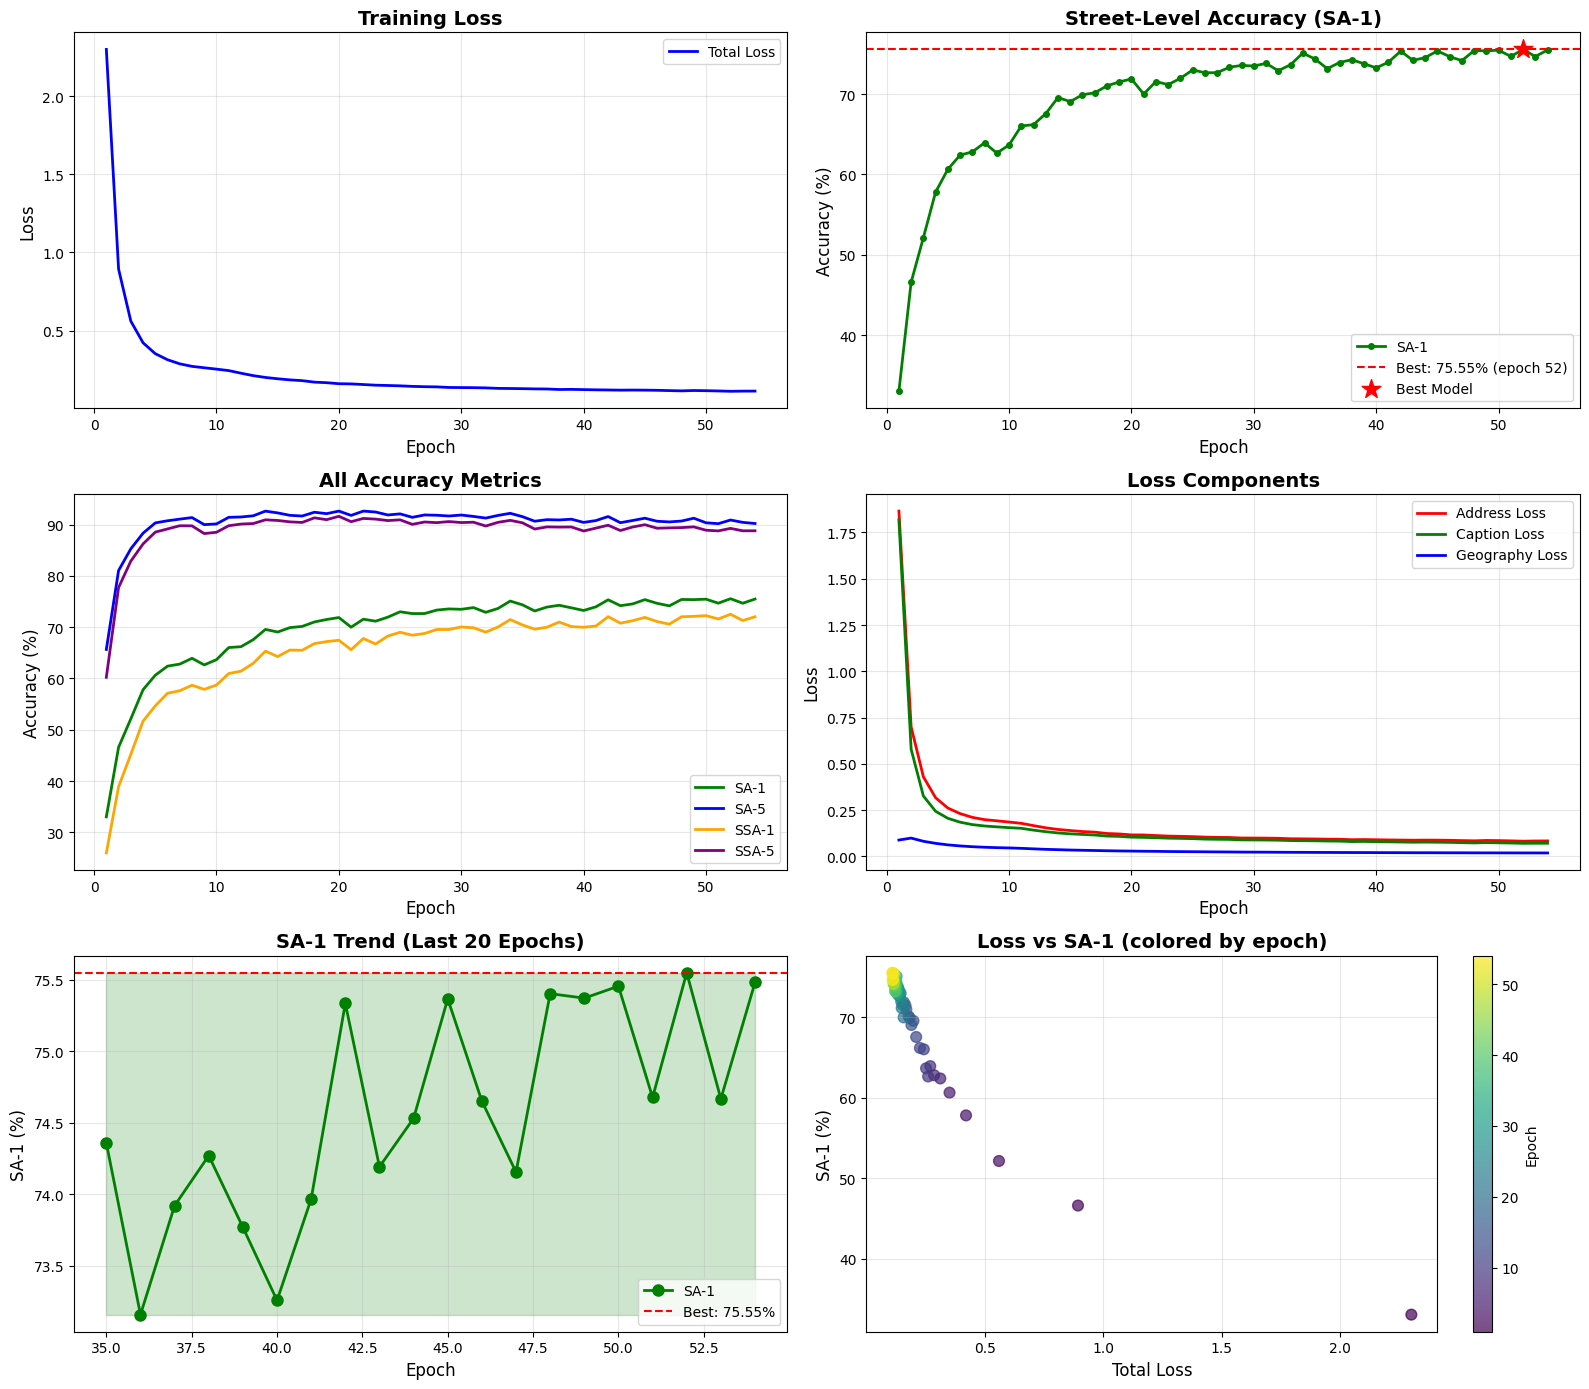


✅ Summary saved to:
   ./runs/addressclip2/training_summary.txt

✅ ANALYSIS COMPLETE


: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load training log
df = pd.read_csv("./runs/addressclip2/log.csv")

print("="*70)
print("COMPREHENSIVE TRAINING ANALYSIS")
print("="*70)

# Summary statistics
print(f"\n📊 Overall Statistics:")
print(f"   Total epochs completed: {len(df)}")
print(f"   Peak SA-1: {df['SA1'].max():.2f}% (epoch {df['SA1'].idxmax() + 1})")
print(f"   Peak SSA-1: {df['SSA1'].max():.2f}% (epoch {df['SSA1'].idxmax() + 1})")
print(f"   Final loss: {df['loss'].iloc[-1]:.4f}")

# Plateau analysis
print(f"\n🔍 Plateau Analysis:")
last_10 = df.tail(10)
last_20 = df.tail(20)

improvement_10 = last_10['SA1'].max() - last_10['SA1'].min()
improvement_20 = last_20['SA1'].max() - last_20['SA1'].min()

print(f"   Last 10 epochs:")
print(f"     SA-1 range: {last_10['SA1'].min():.2f}% - {last_10['SA1'].max():.2f}%")
print(f"     Improvement: {improvement_10:.2f}%")
print(f"   Last 20 epochs:")
print(f"     SA-1 range: {last_20['SA1'].min():.2f}% - {last_20['SA1'].max():.2f}%")
print(f"     Improvement: {improvement_20:.2f}%")

if improvement_10 < 0.5:
    print(f"\n   ⚠️  VERDICT: Training has PLATEAUED")
    print(f"      < 0.5% improvement in last 10 epochs")
    print(f"      ✅ Stopping was the right decision!")
elif improvement_10 < 1.0:
    print(f"\n   ⚠️  VERDICT: Training is SLOWING DOWN")
    print(f"      < 1% improvement in last 10 epochs")
    print(f"      ✅ Stopping is reasonable")
else:
    print(f"\n   ℹ️  VERDICT: Still improving steadily")
    print(f"      Might benefit from more training")

# Training efficiency
total_time_hours = len(df) * 4.8  # 4.8 hours per epoch
print(f"\n⏱️  Time Investment:")
print(f"   Total training time: ~{total_time_hours:.1f} hours ({total_time_hours/24:.1f} days)")
print(f"   Time per epoch: ~4.8 hours")
print(f"   Epochs saved by stopping early: {100 - len(df)}")
print(f"   Time saved: ~{(100 - len(df)) * 4.8:.1f} hours ({(100 - len(df)) * 4.8 / 24:.1f} days)")

# Create comprehensive visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Loss over time
axes[0, 0].plot(df['epoch'], df['loss'], 'b-', linewidth=2, label='Total Loss')
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=10)

# 2. SA-1 over time with best marker
best_epoch = df['SA1'].idxmax() + 1
best_sa1 = df['SA1'].max()
axes[0, 1].plot(df['epoch'], df['SA1'], 'g-', linewidth=2, marker='o', 
                markersize=4, label='SA-1')
axes[0, 1].axhline(y=best_sa1, color='r', linestyle='--', linewidth=1.5, 
                   label=f'Best: {best_sa1:.2f}% (epoch {best_epoch})')
axes[0, 1].scatter([best_epoch], [best_sa1], color='red', s=200, 
                   marker='*', zorder=5, label='Best Model')
axes[0, 1].set_title('Street-Level Accuracy (SA-1)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=10)

# 3. All SA metrics
axes[1, 0].plot(df['epoch'], df['SA1'], 'g-', linewidth=2, label='SA-1')
axes[1, 0].plot(df['epoch'], df['SA5'], 'b-', linewidth=2, label='SA-5')
axes[1, 0].plot(df['epoch'], df['SSA1'], 'orange', linewidth=2, label='SSA-1')
axes[1, 0].plot(df['epoch'], df['SSA5'], 'purple', linewidth=2, label='SSA-5')
axes[1, 0].set_title('All Accuracy Metrics', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=10)

# 4. Loss components
axes[1, 1].plot(df['epoch'], df['L_addr'], 'r-', linewidth=2, label='Address Loss')
axes[1, 1].plot(df['epoch'], df['L_cap'], 'g-', linewidth=2, label='Caption Loss')
axes[1, 1].plot(df['epoch'], df['L_geo'], 'b-', linewidth=2, label='Geography Loss')
axes[1, 1].set_title('Loss Components', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Loss', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=10)

# 5. Recent SA-1 trend (last 20 epochs)
recent = df.tail(20)
axes[2, 0].plot(recent['epoch'], recent['SA1'], 'go-', linewidth=2, 
                markersize=8, label='SA-1')
axes[2, 0].axhline(y=best_sa1, color='r', linestyle='--', linewidth=1.5, 
                   label=f'Best: {best_sa1:.2f}%')
axes[2, 0].fill_between(recent['epoch'], 
                         recent['SA1'].min(), recent['SA1'].max(), 
                         alpha=0.2, color='green')
axes[2, 0].set_title('SA-1 Trend (Last 20 Epochs)', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Epoch', fontsize=12)
axes[2, 0].set_ylabel('SA-1 (%)', fontsize=12)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend(fontsize=10)

# 6. Loss vs Accuracy correlation
axes[2, 1].scatter(df['loss'], df['SA1'], c=df['epoch'], 
                  cmap='viridis', s=60, alpha=0.7)
axes[2, 1].set_title('Loss vs SA-1 (colored by epoch)', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Total Loss', fontsize=12)
axes[2, 1].set_ylabel('SA-1 (%)', fontsize=12)
axes[2, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[2, 1].collections[0], ax=axes[2, 1])
cbar.set_label('Epoch', fontsize=10)

plt.tight_layout()
plt.savefig('./runs/addressclip2/training_analysis_final.png', 
            dpi=150, bbox_inches='tight')
print(f"\n✅ Comprehensive analysis saved to:")
print(f"   ./runs/addressclip2/training_analysis_final.png")
plt.show()

# Export summary to text file
summary_text = f"""
ADDRESSCLIP TRAINING SUMMARY
{'='*70}

Training Configuration:
- Total epochs planned: 100
- Epochs completed: {len(df)}
- Stopped at: Epoch {len(df)}

Best Results:
- Best SA-1: {best_sa1:.2f}% (Epoch {best_epoch})
- Best SA-5: {df['SA5'].max():.2f}%
- Best SSA-1: {df['SSA1'].max():.2f}%
- Best SSA-5: {df['SSA5'].max():.2f}%

Final Results:
- Final SA-1: {df['SA1'].iloc[-1]:.2f}%
- Final Loss: {df['loss'].iloc[-1]:.4f}

Plateau Analysis:
- Last 10 epochs SA-1 range: {last_10['SA1'].min():.2f}% - {last_10['SA1'].max():.2f}%
- Improvement in last 10 epochs: {improvement_10:.2f}%
- Verdict: {'PLATEAUED' if improvement_10 < 0.5 else 'SLOWING DOWN' if improvement_10 < 1.0 else 'STILL IMPROVING'}

Time Investment:
- Total training time: ~{total_time_hours:.1f} hours ({total_time_hours/24:.1f} days)
- Time per epoch: ~4.8 hours
- Time saved by early stopping: ~{(100 - len(df)) * 4.8:.1f} hours

Model Files:
- Best model: ./runs/addressclip2/best.pt (Epoch {best_epoch})
- Training log: ./runs/addressclip2/log.csv
"""

with open('./runs/addressclip2/training_summary.txt', 'w') as f:
    f.write(summary_text)

print(f"\n✅ Summary saved to:")
print(f"   ./runs/addressclip2/training_summary.txt")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE")
print("="*70)

In [ ]:
# ============================================
# VISUALIZATIONS
# ============================================

print("\n📊 Generating visualizations...")

# Loss curves
plt.figure(figsize=(10, 6))
plt.plot(history["epoch"], history["loss"], 'o-', label="Total loss", linewidth=2)
plt.plot(history["epoch"], history["L_addr"], 's-', label="L_address", linewidth=2)
plt.plot(history["epoch"], history["L_cap"], '^-', label="L_caption", linewidth=2)
plt.plot(history["epoch"], history["L_geo"], 'd-', label="L_geography", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training Losses", fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(LOSS_PNG, dpi=150)
plt.show()

# Accuracy curves
plt.figure(figsize=(10, 6))
plt.plot(history["epoch"], history["SSA1"], 'o-', label="SSA-1", linewidth=2)
plt.plot(history["epoch"], history["SSA5"], 's-', label="SSA-5", linewidth=2)
plt.plot(history["epoch"], history["SA1"], '^-', label="SA-1", linewidth=2)
plt.plot(history["epoch"], history["SA5"], 'd-', label="SA-5", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Retrieval Accuracy", fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ACC_PNG, dpi=150)
plt.show()
print(f"\n✓ Saved visualizations:")
print(f"   {LOSS_PNG}")
print(f"   {ACC_PNG}")
print(f"   {CSV_LOG}")

print("\n✅ ALL DONE!")

In [ ]:
#older code for training loop and evaluation (before refactoring and improvements)

In [ ]:
# import torch
# import torch.nn.functional as F
# from torch.optim import AdamW
# from tqdm import tqdm
# import matplotlib.pyplot as plt
# import clip
# import csv
# import math
# import os
# import time
# import random
# import numpy as np
# from dataclasses import asdict  # Assuming CFG is a dataclass

# # Set paths (updated to match new structure)
# RUN_DIR = "./runs/addressclip2"
# os.makedirs(RUN_DIR, exist_ok=True)
# CSV_LOG = os.path.join(RUN_DIR, "log.csv")
# LOSS_PNG = os.path.join(RUN_DIR, "loss.png")
# ACC_PNG = os.path.join(RUN_DIR, "acc.png")
# SAMPLES_PNG = os.path.join(RUN_DIR, "samples.png")
# best_path = os.path.join(RUN_DIR, "best.pt")
# last_path = os.path.join(RUN_DIR, "last.pt")

# # Optimizer Setup
# def build_optimizer(model: AddressCLIP):
#     heads = list(model.proj_image.parameters()) + list(model.proj_address.parameters()) + list(model.proj_caption.parameters())
#     backbone = [p for p in model.clip.parameters() if p.requires_grad]
#     return AdamW([
#         {"params": heads, "lr": CFG.lr_heads},
#         {"params": backbone, "lr": CFG.lr_backbone},
#     ], weight_decay=CFG.weight_decay)

# # Learning rate scheduler
# def cosine_schedule(optimizer, num_warmup, num_total):
#     def lr_lambda(step):
#         if step < num_warmup:
#             return max(step / float(max(1, num_warmup)), 1e-6)
#         prog = (step - num_warmup) / float(max(1, num_total - num_warmup))
#         return 0.5 * (1 + math.cos(math.pi * prog))
#     return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# # Evaluation Functions
# @torch.no_grad()
# def eval_gallery_addresses(model: AddressCLIP, texts: List[str], bs: int = 256) -> torch.Tensor:
#     model.eval()
#     vecs = []
#     for i in range(0, len(texts), bs):
#         toks = clip.tokenize(texts[i:i+bs], truncate=True).to(CFG.device)
#         with torch.autocast(device_type="cuda", enabled=False):
#             z = model.encode_text(toks, which="address").to(torch.float32)
#             z = F.normalize(z, dim=-1)
#         vecs.append(z)
#     return torch.cat(vecs, 0)

# @torch.no_grad()
# def eval_query_images(model: AddressCLIP, loader, return_images: bool = False) -> Tuple[torch.Tensor, List[str], Optional[List[torch.Tensor]]]:
#     model.eval()
#     vecs = []
#     gts = []
#     imgs_list = [] if return_images else None
#     for b in loader:
#         img = b["image"].to(CFG.device, non_blocking=True).to(torch.float32)
#         with torch.autocast(device_type="cuda", enabled=False):
#             v = model.encode_image(img)
#             v = F.normalize(v, dim=-1)
#         vecs.append(v)
#         gts.extend(b["gt"])
#         if return_images:
#             imgs_list.extend([im.cpu() for im in b["image"]])  # Collect individual images as CPU tensors
#     vecs = torch.cat(vecs, 0)
#     if return_images:
#         return vecs, gts, imgs_list
#     return vecs, gts

# @torch.no_grad()
# def evaluate_sa(model: AddressCLIP) -> Tuple[float, float]:
#     gallery_texts = db_ds.text
#     gallery_norm = db_ds.norm
#     A = eval_gallery_addresses(model, gallery_texts, bs=256)  # [G, d]
#     V, gt_norm = eval_query_images(model, queries_loader)  # [Q, d]
#     S = V @ A.t()
#     topk = torch.topk(S, k=5, dim=1).indices.cpu().numpy()
#     sa1 = sa5 = 0
#     for i, gt in enumerate(gt_norm):
#         preds = [gallery_norm[j] for j in topk[i][:5]]
#         if gt == preds[0]:
#             sa1 += 1
#         if gt in preds:
#             sa5 += 1
#     Q = len(gt_norm)
#     return 100.0 * sa1 / Q, 100.0 * sa5 / Q


# # Model Initialization
# num_updates = (len(train_loader) // CFG.grad_accum) * CFG.epochs
# Import MiniGPT-4 model components (adjust imports based on your setup)
# from minigpt4.common.config import Config
# from minigpt4.common.registry import registry
# from minigpt4.conversation.conversation import Chat, CONV_VISION
# warmup = int(CFG.warmup_ratio * max(1, num_updates))
# model = AddressCLIP(proj_dim=512, freeze_visual=True, freeze_text=True, device=CFG.device).to(CFG.device)
# opt = build_optimizer(model)
# sched = cosine_schedule(opt, warmup, num_updates)
# scaler = torch.cuda.amp.GradScaler(enabled=CFG.fp16)
# history = {"epoch": [], "loss": [], "L_addr": [], "L_cap": [], "L_geo": [], "SA1": [], "SA5": []}
# with open(CSV_LOG, "w", newline="") as f:
#     csv.writer(f).writerow(["epoch", "loss", "L_addr", "L_cap", "L_geo", "SA1", "SA5"])

# # Training
# start = time.time()
# best_sa1 = -1.0
# for ep in range(CFG.epochs):
#     stats = train_epoch(ep)
#     sa1, sa5 = evaluate_sa(model)
#     # log
#     history["epoch"].append(ep + 1)
#     history["loss"].append(stats["total"])
#     history["L_addr"].append(stats["addr"])
#     history["L_cap"].append(stats["cap"])
#     history["L_geo"].append(stats["geo"])
#     history["SA1"].append(sa1)
#     history["SA5"].append(sa5)
#     with open(CSV_LOG, "a", newline="") as f:
#         csv.writer(f).writerow([ep + 1, stats["total"], stats["addr"], stats["cap"], stats["geo"], sa1, sa5])
#     print(f"[E{ep+1:02d}] loss={stats['total']:.4f} | L_addr={stats['addr']:.4f} | "
#           f"L_cap={stats['cap']:.4f} | L_geo={stats['geo']:.4f} | SA-1={sa1:.2f}% | SA-5={sa5:.2f}%")
#     # Checkpointing: Keep best by SA-1
#     if sa1 > best_sa1:
#         best_sa1 = sa1
#         torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "history": history}, best_path)

# # Save last checkpoint
# torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "history": history}, last_path)
# print(f"Training+Eval finished in {(time.time() - start) / 60:.1f} min. Best SA-1: {best_sa1:.2f}%")

# # Visualization: Training losses and accuracies
# plt.figure(figsize=(6, 4))
# plt.plot(history["epoch"], history["loss"], label="Total loss")
# plt.plot(history["epoch"], history["L_addr"], label="L_address")
# plt.plot(history["epoch"], history["L_cap"], label="L_caption")
# plt.plot(history["epoch"], history["L_geo"], label="L_geography")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training losses")
# plt.legend()
# plt.tight_layout()
# plt.savefig(LOSS_PNG)
# plt.show()

# plt.figure(figsize=(6, 4))
# plt.plot(history["epoch"], history["SA1"], label="SA-1")
# plt.plot(history["epoch"], history["SA5"], label="SA-5")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy (%)")
# plt.title("Street-level Accuracy")
# plt.legend()
# plt.tight_layout()
# plt.savefig(ACC_PNG)
# plt.show()



epoch 1/30:   0%|          | 0/11115 [00:00<?, ?it/s]/home/khush/anaconda3/envs/major_project/lib/python3.8/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,
epoch 1/30: 100%|██████████| 11115/11115 [19:45<00:00,  9.38it/s]


[E01] loss=1.8061 | L_addr=1.4077 | L_cap=1.1372 | L_geo=0.2137 | SA-1=12.41% | SA-5=35.94%


epoch 2/30: 100%|██████████| 11115/11115 [19:45<00:00,  9.37it/s]


[E02] loss=1.5158 | L_addr=1.1509 | L_cap=0.9805 | L_geo=0.2110 | SA-1=12.07% | SA-5=35.95%


epoch 3/30: 100%|██████████| 11115/11115 [48:10<00:00,  3.84it/s]


...

epoch 14/30: 100%|██████████| 11115/11115 [48:07<00:00,  3.85it/s]


[E14] loss=1.3524 | L_addr=0.9924 | L_cap=0.9164 | L_geo=0.2209 | SA-1=16.08% | SA-5=43.01%


epoch 15/30: 100%|██████████| 11115/11115 [48:07<00:00,  3.85it/s]


[E15] loss=1.3352 | L_addr=0.9753 | L_cap=0.9114 | L_geo=0.2220 | SA-1=16.26% | SA-5=43.43%


epoch 16/30:   3%|▎         | 354/11115 [01:32<46:31,  3.86it/s]

epoch 1/100:   0%|          | 1/5557 [00:00<1:02:06,  1.49it/s]

Initialized coord normalization: min=tensor([[ 583562.3125, 4476446.0000]], device='cuda:0'), max=tensor([[ 586489.1250, 4479092.0000]], device='cuda:0')


epoch 1/100: 100%|██████████| 5557/5557 [18:41<00:00,  4.96it/s]


[E01] loss=3.0837 | L_addr=2.1444 | L_cap=1.6868 | L_geo=0.4794 | SA-1=14.64% | SA-5=39.81%


epoch 2/100: 100%|██████████| 5557/5557 [18:38<00:00,  4.97it/s]


...

[E98] loss=1.5065 | L_addr=0.8645 | L_cap=0.9861 | L_geo=0.7446 | SA-1=30.81% | SA-5=63.83%


epoch 99/100: 100%|██████████| 5557/5557 [45:28<00:00,  2.04it/s]


[E99] loss=1.5023 | L_addr=0.8616 | L_cap=0.9833 | L_geo=0.7449 | SA-1=30.86% | SA-5=63.99%


epoch 100/100: 100%|██████████| 5557/5557 [45:28<00:00,  2.04it/s]


[E100] loss=1.5004 | L_addr=0.8597 | L_cap=0.9830 | L_geo=0.7457 | SA-1=30.86% | SA-5=63.98%
Training+Eval finished in 4938.0 min. Best SA-1: 30.86%


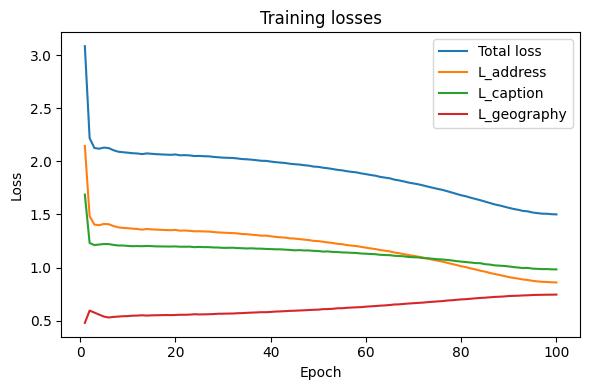

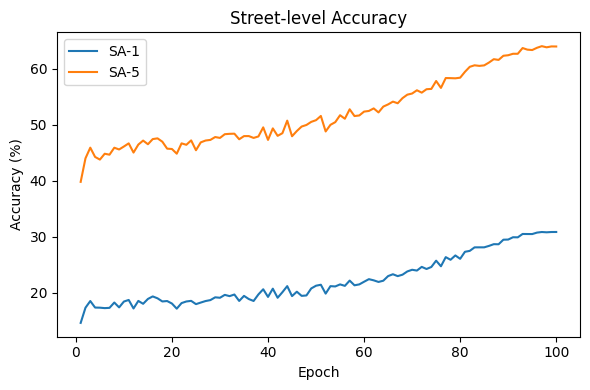

Saved CSV log to: ./runs/addressclip/train_log.csv
Saved plots to:   ./runs/addressclip/loss_curve.png and ./runs/addressclip/accuracy_curve.png


In [ ]:
#                                                    FIRSTLY WRITTEN CODE

# import torch
# import torch.nn.functional as F
# from torch.optim import AdamW
# from tqdm import tqdm
# import matplotlib.pyplot as plt
# import clip
# import csv
# import math


# # Optimizer Setup
# def build_optimizer(model: AddressCLIP):
#     heads = list(model.proj_image.parameters()) + list(model.proj_address.parameters()) + list(model.proj_caption.parameters())
#     backbone = [p for p in model.clip.parameters() if p.requires_grad]
#     return AdamW([
#         {"params": heads, "lr": CFG.lr_heads},
#         {"params": backbone, "lr": CFG.lr_backbone},
#     ], weight_decay=CFG.weight_decay)

# # Learning rate scheduler
# def cosine_schedule(optimizer, num_warmup, num_total):
#     def lr_lambda(step):
#         if step < num_warmup:
#             return max(step/float(max(1, num_warmup)), 1e-6)
#         prog = (step - num_warmup) / float(max(1, num_total - num_warmup))
#         return 0.5*(1 + math.cos(math.pi * prog))
#     return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# # Evaluation Functions
# @torch.no_grad()
# def eval_gallery_addresses(model: AddressCLIP, texts: List[str], bs: int = 256) -> torch.Tensor:
#     model.eval()
#     vecs = []
#     for i in range(0, len(texts), bs):
#         toks = clip.tokenize(texts[i:i+bs], truncate=True).to(CFG.device)
#         with torch.autocast(device_type="cuda", enabled=False):
#             z = model.encode_text(toks, which="address").to(torch.float32)
#             z = F.normalize(z, dim=-1)
#         vecs.append(z)
#     return torch.cat(vecs, 0)

# @torch.no_grad()
# def eval_query_images(model: AddressCLIP, loader) -> Tuple[torch.Tensor, List[str]]:
#     model.eval()
#     vecs = []; gts = []
#     for b in loader:
#         img = b["image"].to(CFG.device, non_blocking=True).to(torch.float32)
#         with torch.autocast(device_type="cuda", enabled=False):
#             v = model.encode_image(img)
#             v = F.normalize(v, dim=-1)
#         vecs.append(v)
#         gts.extend(b["gt"])
#     return torch.cat(vecs, 0), gts

# @torch.no_grad()
# def evaluate_sa(model: AddressCLIP) -> Tuple[float, float]:
#     gallery_texts = db_ds.text
#     gallery_norm  = db_ds.norm
#     A = eval_gallery_addresses(model, gallery_texts, bs=256)   # [G, d]
#     V, gt_norm = eval_query_images(model, queries_loader)      # [Q, d]
#     S = V @ A.t()
#     topk = torch.topk(S, k=5, dim=1).indices.cpu().numpy()
#     sa1 = sa5 = 0
#     for i, gt in enumerate(gt_norm):
#         preds = [gallery_norm[j] for j in topk[i][:5]]
#         if gt == preds[0]: sa1 += 1
#         if gt in preds: sa5 += 1
#     Q = len(gt_norm)
#     return 100.0 * sa1 / Q, 100.0 * sa5 / Q


# # Model Initialization
# model = AddressCLIP(proj_dim=512, freeze_visual=True, freeze_text=True, device=CFG.device).to(CFG.device)
# opt = build_optimizer(model)
# num_updates = (len(train_loader) // CFG.grad_accum) * CFG.epochs
# warmup = int(CFG.warmup_ratio * max(1, num_updates))
# sched = cosine_schedule(opt, warmup, max(1, num_updates))
# scaler = torch.cuda.amp.GradScaler(enabled=CFG.fp16)

# history = {"epoch": [], "loss": [], "L_addr": [], "L_cap": [], "L_geo": [], "SA1": [], "SA5": []}

# with open(CSV_LOG, "w", newline="") as f:
#     csv.writer(f).writerow(["epoch", "loss", "L_addr", "L_cap", "L_geo", "SA1", "SA5"])


# # Training Loop
# def train_epoch(epoch: int):
#     model.train()

#     if epoch >= CFG.freeze_epochs:
#         for p in model.clip.parameters():
#             p.requires_grad = True

#     running = {"addr": 0.0, "cap": 0.0, "geo": 0.0, "total": 0.0}
#     opt.zero_grad(set_to_none=True)
#     for it, batch in enumerate(tqdm(train_loader, desc=f"epoch {epoch+1}/{CFG.epochs}")):
#         imgs = batch["images"].to(CFG.device, non_blocking=True)
#         atok = batch["addr_tokens"].to(CFG.device, non_blocking=True)
#         ctok = batch["cap_tokens"].to(CFG.device, non_blocking=True)
#         coords = batch["coords"].to(CFG.device, non_blocking=True)

#         with torch.cuda.amp.autocast(enabled=CFG.fp16):
#             v, a, c, geo = model(imgs, atok, ctok, coords)  # Get embeddings for image, address, caption, and coordinates

#             L_addr = clip_info_nce(v @ a.t(), CFG.tau)
#             L_cap = clip_info_nce(v @ c.t(), CFG.tau)

#             L_geo = compute_geography_loss(v, geo)

#             loss = CFG.lambda_addr * L_addr + CFG.lambda_cap * L_cap + CFG.lambda_geo * L_geo

#         scaler.scale(loss / CFG.grad_accum).backward()
#         if (it + 1) % CFG.grad_accum == 0:
#             scaler.step(opt)
#             scaler.update()
#             opt.zero_grad(set_to_none=True)
#             sched.step()

#         running["addr"] += L_addr.item()
#         running["cap"] += L_cap.item()
#         running["geo"] += L_geo.item()
#         running["total"] += loss.item()


#     steps = max(1, len(train_loader))
#     for k in running:
#         running[k] /= steps
#     return running


# start = time.time()
# best_sa1 = -1.0
# best_path = os.path.join(RUN_DIR, "best.pt")

# for ep in range(CFG.epochs):
#     stats = train_epoch(ep)
#     sa1, sa5 = evaluate_sa(model)

#     # log
#     history["epoch"].append(ep + 1)
#     history["loss"].append(stats["total"])
#     history["L_addr"].append(stats["addr"])
#     history["L_cap"].append(stats["cap"])
#     history["L_geo"].append(stats["geo"])  
#     history["SA1"].append(sa1)
#     history["SA5"].append(sa5)

#     with open(CSV_LOG, "a", newline="") as f:
#         csv.writer(f).writerow([ep + 1, stats["total"], stats["addr"], stats["cap"], stats["geo"], sa1, sa5])

#     print(f"[E{ep+1:02d}] loss={stats['total']:.4f} | L_addr={stats['addr']:.4f} | "
#           f"L_cap={stats['cap']:.4f} | L_geo={stats['geo']:.4f} | SA-1={sa1:.2f}% | SA-5={sa5:.2f}%")

#     # Keep best by SA-1
#     if sa1 > best_sa1:
#         best_sa1 = sa1
#         torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "history": history}, best_path)

# # Save last
# torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "history": history}, os.path.join(RUN_DIR, "last.pt"))
# print(f"Training+Eval finished in {(time.time() - start) / 60:.1f} min. Best SA-1: {best_sa1:.2f}%")


# plt.figure(figsize=(6, 4))
# plt.plot(history["epoch"], history["loss"], label="Total loss")
# plt.plot(history["epoch"], history["L_addr"], label="L_address")
# plt.plot(history["epoch"], history["L_cap"], label="L_caption")
# plt.plot(history["epoch"], history["L_geo"], label="L_geography")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training losses")
# plt.legend()
# plt.tight_layout()
# plt.savefig(LOSS_PNG)
# plt.show()

# plt.figure(figsize=(6, 4))
# plt.plot(history["epoch"], history["SA1"], label="SA-1")
# plt.plot(history["epoch"], history["SA5"], label="SA-5")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy (%)")
# plt.title("Street-level Accuracy")
# plt.legend()
# plt.tight_layout()
# plt.savefig(ACC_PNG)
# plt.show()

# print(f"Saved CSV log to: {CSV_LOG}")
# print(f"Saved plots to:   {LOSS_PNG} and {ACC_PNG}")